In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/financials_features.parquet
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/._financials_features.parquet
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/transactions_features.parquet
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/SampleSubmission.csv
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/._transactions_features.parquet
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/Train (1).csv
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/._demographics_clean.parquet
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/VariableDefinitions.csv
/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

SEED = 42 
np.random.seed(SEED)


In [2]:
path = "/kaggle/input/datasets/tshiamomatshaba/nedbank-transaction-volume-forecasting-challenge/"

In [3]:
#Load files
train = pd.read_csv(path + "Train (1).csv") 
test = pd.read_csv(path + "Test.csv") 
txn = pd.read_parquet(path + "transactions_features.parquet")  
fin = pd.read_parquet(path + "financials_features.parquet") 
demo = pd.read_parquet(path + "demographics_clean.parquet")  

In [4]:
#Check the shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Transactional shape:", txn.shape)
print("Financial shape:", fin.shape)
print("Demographic shape:", demo.shape)

Train shape: (8360, 2)
Test shape: (3584, 1)
Transactional shape: (18017073, 9)
Financial shape: (372245, 6)
Demographic shape: (11944, 17)


In [5]:
#Preview first few rows of each
print("\nTrain head:")
print(train.head())
print("\nTest head:")
print(test.head())
print("\nTransactions head:")
print(txn.head())
print("\nFinancials head:")
print(fin.head())
print("\nDemographics head:")
print(demo.head())


Train head:
                               UniqueID  next_3m_txn_count
0  00093e2d-9e1e-4061-ad27-a79b8ff9e165                129
1  0011d60f-a4e2-4333-81fc-2d557a82109b                 16
2  0016f1e2-64c1-4c65-a668-1dc6bf3b5875                117
3  001aa3c5-632d-435e-a421-cc3615ccef4d                 70
4  00298c6f-4f9d-4f28-b72c-ad0e56e9eb84                393

Test head:
                               UniqueID
0  6b62ce75-9823-4de6-ba7b-8b2b199df239
1  e193e600-a706-4bc6-8597-d5d6fb171ab5
2  8fd44803-12ed-46ab-a146-8496d95d1b13
3  12606376-113f-4c90-94b9-65f64f9fa8c7
4  da070817-27ed-44b2-bc05-e817ea311519

Transactions head:
                               UniqueID                             AccountID  \
0  d7b4459e-41bc-4ab6-98e4-0bfe01a4dfe5  bc348826-aa16-4b71-a2f7-0a78b9cf84cc   
1  58c224c1-4f38-440f-9c78-b6d5a818839e  1e2e57bc-1ef7-4f0b-8408-861d34065fd5   
2  4e0dfceb-7186-4b71-bb0d-0e39baa31979  51e7813b-a259-43b6-940f-feb0c2d8199e   
3  ed2ef2a9-0947-45e6-8f7b-023e88a79c

Target statistics:
count    8360.000000
mean      144.969019
std       152.156725
min         1.000000
25%        35.000000
50%       102.000000
75%       201.000000
max      1794.000000
Name: next_3m_txn_count, dtype: float64


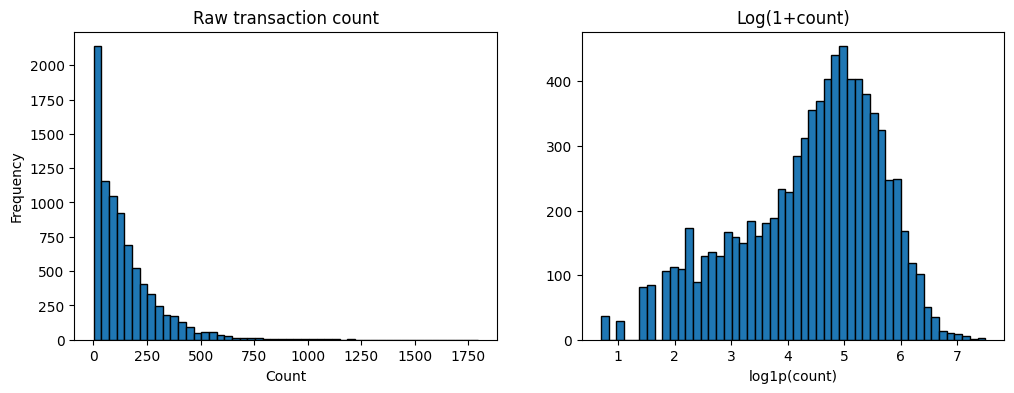

In [7]:
#Target distribution 
print("Target statistics:")
print(train["next_3m_txn_count"].describe())

#Plot histograms
fig, (ax1, ax2)=plt.subplots(1,2, figsize=(12,4))
ax1.hist(train["next_3m_txn_count"], bins=50, edgecolor="black")
ax1.set_title("Raw transaction count")
ax1.set_xlabel("Count")
ax1.set_ylabel("Frequency")

log_target = np.log1p(train["next_3m_txn_count"])
ax2.hist(log_target, bins=50, edgecolor="black")
ax2.set_title("Log(1+count)")
ax2.set_xlabel("log1p(count)")
plt.show()

In [8]:
# Simple baseline: predict median of training target for all test customers
median_train = train['next_3m_txn_count'].median()
print(f"\nMedian of training target: {median_train}")

# Compute RMSLE of this baseline on training (just for illustration)
baseline_pred = np.full(len(train), median_train)
baseline_rmsle = np.sqrt(mean_squared_error(np.log1p(train['next_3m_txn_count']), np.log1p(baseline_pred)))
print(f"Baseline RMSLE on training set (using median): {baseline_rmsle:.6f}")



Median of training target: 102.0
Baseline RMSLE on training set (using median): 1.276669


In [9]:
# Create a valid submission file using median baseline (remember to log1p)
sub_baseline = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': np.log1p(median_train)   # log1p of median
})
sub_baseline.to_csv('submission_baseline.csv', index=False)
print("\nBaseline submission saved as 'submission_baseline.csv'")
print("First 5 rows:")
print(sub_baseline.head())


Baseline submission saved as 'submission_baseline.csv'
First 5 rows:
                               UniqueID  next_3m_txn_count
0  6b62ce75-9823-4de6-ba7b-8b2b199df239           4.634729
1  e193e600-a706-4bc6-8597-d5d6fb171ab5           4.634729
2  8fd44803-12ed-46ab-a146-8496d95d1b13           4.634729
3  12606376-113f-4c90-94b9-65f64f9fa8c7           4.634729
4  da070817-27ed-44b2-bc05-e817ea311519           4.634729


In [10]:
# Quick check: correlation with target
# First merge features with target
train_with_features = X_train_roll.merge(train, on='UniqueID', how='left')
# Drop UniqueID for correlation
feature_cols = [col for col in train_with_features.columns if col not in ['UniqueID', 'next_3m_txn_count']]
corr_data = train_with_features[feature_cols + ['next_3m_txn_count']].corr()
corr_with_target = corr_data['next_3m_txn_count'].sort_values(ascending=False)
print("\nCorrelation with target (top features):")
print(corr_with_target.head(10))

NameError: name 'X_train_roll' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

# Prepare data: drop UniqueID
feature_cols = [col for col in X_train_roll.columns if col != 'UniqueID']
X = X_train_roll[feature_cols]
y = train['next_3m_txn_count']

# Transform target to log space (RMSLE)
y_log = np.log1p(y)

# Simple random split (temporary - we'll improve validation later)
X_train_simple, X_val_simple, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Train LightGBM
model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

model.fit(X_train_simple, y_train_log)
val_pred_log = model.predict(X_val_simple)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))

print(f"Validation RMSLE (simple rolling features): {val_rmsle:.6f}")

In [ ]:
# Get last transaction date per customer
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']

# Merge into training features
X_train_time = X_train_roll.merge(last_txn, on='UniqueID', how='left')
# Fill missing (customers with no transactions) with oldest date
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))

# Sort by last transaction date
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
# Align target
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

# Use last 20% of customers (most recent) as validation
split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

print(f"Train size (time-based): {len(X_tr)}")
print(f"Validation size: {len(X_val)}")

# Train again
model_time = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
model_time.fit(X_tr, y_tr_log)
val_pred_log_time = model_time.predict(X_val)
val_rmsle_time = np.sqrt(mean_squared_error(y_val_log, val_pred_log_time))
print(f"\nValidation RMSLE (time-based split): {val_rmsle_time:.6f}")

In [ ]:
# Get transaction types and filter last 90 days
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()

# Count by transaction type per customer
type_counts = txn_last_90d.groupby(['UniqueID', 'TransactionTypeDescription']).size().unstack(fill_value=0)
type_counts.columns = [f'txn_type_{col}' for col in type_counts.columns]
type_counts = type_counts.reset_index()

print("Transaction type features shape:", type_counts.shape)
print(type_counts.head())

# Merge with existing rolling features
X_train_types = X_train_roll.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_test_types = X_test_roll.merge(type_counts, on='UniqueID', how='left').fillna(0)

# Update feature columns
feature_cols = [col for col in X_train_types.columns if col != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")
print("Sample features:", feature_cols[:10])

# Quick re-train with same time-based split to see improvement
X_train_time_types = X_train_types.merge(last_txn, on='UniqueID', how='left')
X_train_time_types['last_txn_date'] = X_train_time_types['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time_types = X_train_time_types.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time_types['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time_types))
X_tr = X_train_time_types.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time_types.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

model_types = lgb.LGBMRegressor(objective='regression', metric='rmse', n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
model_types.fit(X_tr, y_tr_log)
val_pred_log = model_types.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
print(f"\nValidation RMSLE with transaction types: {val_rmsle:.6f}")

In [ ]:
# Debit/credit counts in last 90 days
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()
dc_counts = txn_last_90d.groupby(['UniqueID', 'IsDebitCredit']).size().unstack(fill_value=0)
dc_counts.columns = [f'txn_{col.lower()}_count' for col in dc_counts.columns]
dc_counts = dc_counts.reset_index()

# Seasonal feature: transaction count in same 3-month window previous year (Nov 2014 - Jan 2015)
season_start = pd.Timestamp('2014-11-01')
season_end = pd.Timestamp('2015-01-31')
season_mask = (txn_hist['TransactionDate'] >= season_start) & (txn_hist['TransactionDate'] <= season_end)
season_txn = txn_hist[season_mask].copy()
season_count = season_txn.groupby('UniqueID').size().rename('txn_count_same_season_prev_year').reset_index()

# Merge new features
X_train_new = X_train_types.merge(dc_counts, on='UniqueID', how='left').fillna(0)
X_train_new = X_train_new.merge(season_count, on='UniqueID', how='left').fillna(0)

X_test_new = X_test_types.merge(dc_counts, on='UniqueID', how='left').fillna(0)
X_test_new = X_test_new.merge(season_count, on='UniqueID', how='left').fillna(0)

# Update feature columns
feature_cols = [col for col in X_train_new.columns if col != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")
print("New features added:", [c for c in X_train_new.columns if c not in X_train_types.columns])

# Re-train with time-based split
X_train_time_new = X_train_new.merge(last_txn, on='UniqueID', how='left')
X_train_time_new['last_txn_date'] = X_train_time_new['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time_new = X_train_time_new.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time_new['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time_new))
X_tr = X_train_time_new.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time_new.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

model_new = lgb.LGBMRegressor(objective='regression', metric='rmse', n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
model_new.fit(X_tr, y_tr_log)
val_pred_log = model_new.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
print(f"\nValidation RMSLE with debit/credit + seasonal lag: {val_rmsle:.6f}")

In [ ]:
# Average transaction amount (last 90 days)
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()
avg_amount = txn_last_90d.groupby('UniqueID')['TransactionAmount'].mean().rename('avg_txn_amount_90d').reset_index()

# Days since last transaction (recency)
last_txn_date = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn_date['days_since_last_txn'] = (CUTOFF_DATE - last_txn_date['TransactionDate']).dt.days
last_txn_date = last_txn_date[['UniqueID', 'days_since_last_txn']]

# Basic demographics (age at cutoff)
demo['BirthDate'] = pd.to_datetime(demo['BirthDate'], errors='coerce')
demo['age_at_cutoff'] = (CUTOFF_DATE - demo['BirthDate']).dt.days / 365.25
demo['age_at_cutoff'] = demo['age_at_cutoff'].clip(18, 100)
demo['age_missing'] = demo['BirthDate'].isna() | (demo['age_at_cutoff'] < 18) | (demo['age_at_cutoff'] > 100)
demo_age = demo[['UniqueID', 'age_at_cutoff', 'age_missing']]

# Merge new features
X_train_new2 = X_train_new.merge(avg_amount, on='UniqueID', how='left').fillna(0)
X_train_new2 = X_train_new2.merge(last_txn_date, on='UniqueID', how='left').fillna(0)
X_train_new2 = X_train_new2.merge(demo_age, on='UniqueID', how='left').fillna(0)

X_test_new2 = X_test_new.merge(avg_amount, on='UniqueID', how='left').fillna(0)
X_test_new2 = X_test_new2.merge(last_txn_date, on='UniqueID', how='left').fillna(0)
X_test_new2 = X_test_new2.merge(demo_age, on='UniqueID', how='left').fillna(0)

# Update feature columns
feature_cols = [col for col in X_train_new2.columns if col != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")
print("New features added:", [c for c in X_train_new2.columns if c not in X_train_new.columns])

# Re-train with time-based split AND early stopping
X_train_time_new2 = X_train_new2.merge(last_txn, on='UniqueID', how='left')
X_train_time_new2['last_txn_date'] = X_train_time_new2['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time_new2 = X_train_time_new2.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time_new2['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time_new2))
X_tr = X_train_time_new2.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time_new2.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

# LightGBM with early stopping
model_final = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

model_final.fit(
    X_tr, y_tr_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

val_pred_log = model_final.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
print(f"\nValidation RMSLE (with all features + early stopping): {val_rmsle:.6f}")
print(f"Best iteration: {model_final.best_iteration_}")

In [ ]:
# One-hot encode IncomeCategory
income_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='income')
income_dummies['UniqueID'] = demo['UniqueID']

# Merge into feature sets
X_train_income = X_train_new2.merge(income_dummies, on='UniqueID', how='left').fillna(0)
X_test_income = X_test_new2.merge(income_dummies, on='UniqueID', how='left').fillna(0)

# Create transaction type ratios (divide each type count by total transaction count)
# Total transactions in last 90 days (use txn_count_last_90d from rolling features)
total_col = 'txn_count_last_90d'
type_cols = [c for c in X_train_income.columns if c.startswith('txn_type_')]

for col in type_cols:
    ratio_col = f'{col}_ratio'
    X_train_income[ratio_col] = X_train_income[col] / (X_train_income[total_col] + 1e-6)
    X_test_income[ratio_col] = X_test_income[col] / (X_test_income[total_col] + 1e-6)

# Also ratio of debits to total transactions
if 'txn_debit_count' in X_train_income.columns:
    X_train_income['debit_ratio'] = X_train_income['txn_debit_count'] / (X_train_income[total_col] + 1e-6)
    X_test_income['debit_ratio'] = X_test_income['txn_debit_count'] / (X_test_income[total_col] + 1e-6)

# Update feature columns
feature_cols = [col for col in X_train_income.columns if col != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")

# Time-based split and retrain
X_train_time = X_train_income.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

model_income = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

model_income.fit(
    X_tr, y_tr_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

val_pred_log = model_income.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
print(f"\nValidation RMSLE (with income + ratios): {val_rmsle:.6f}")
print(f"Best iteration: {model_income.best_iteration_}")

In [ ]:
# Prepare financial snapshot data (only before cutoff)
fin_hist = fin[fin['RunDate'] < CUTOFF_DATE].copy()

# For each customer, compute aggregates from financials
fin_agg = fin_hist.groupby('UniqueID').agg(
    num_financial_months=('RunDate', 'count'),
    avg_net_interest_income=('NetInterestIncome', 'mean'),
    latest_net_interest_income=('NetInterestIncome', 'last'),
    avg_net_interest_revenue=('NetInterestRevenue', 'mean'),
    latest_net_interest_revenue=('NetInterestRevenue', 'last')
).reset_index()

# Trend: difference between last and first (if enough data)
def trend_diff(x):
    if len(x) >= 2:
        return x.iloc[-1] - x.iloc[0]
    else:
        return 0

income_trend = fin_hist.groupby('UniqueID')['NetInterestIncome'].agg(trend_diff).rename('net_interest_income_trend')
revenue_trend = fin_hist.groupby('UniqueID')['NetInterestRevenue'].agg(trend_diff).rename('net_interest_revenue_trend')

fin_agg = fin_agg.merge(income_trend, on='UniqueID', how='left').fillna(0)
fin_agg = fin_agg.merge(revenue_trend, on='UniqueID', how='left').fillna(0)

# Product type indicators (one-hot)
product_dummies = pd.get_dummies(fin_hist[['UniqueID', 'Product']], columns=['Product'], prefix='fin_product')
product_agg = product_dummies.groupby('UniqueID').sum().reset_index()

# Merge all financial features
fin_features = fin_agg.merge(product_agg, on='UniqueID', how='left').fillna(0)
print("Financial features shape:", fin_features.shape)
print(fin_features.head())

# Merge into current feature set
X_train_fin = X_train_income.merge(fin_features, on='UniqueID', how='left').fillna(0)
X_test_fin = X_test_income.merge(fin_features, on='UniqueID', how='left').fillna(0)

# Update feature columns
feature_cols = [col for col in X_train_fin.columns if col != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")

# Time-based split and retrain
X_train_time = X_train_fin.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

model_fin = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

model_fin.fit(
    X_tr, y_tr_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

val_pred_log = model_fin.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred_log))
print(f"\nValidation RMSLE (with financial features): {val_rmsle:.6f}")
print(f"Best iteration: {model_fin.best_iteration_}")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import optuna  # optional, but we'll do manual search for simplicity

# Use features from Step 10 (X_train_income, feature_cols)
# Prepare time-ordered data
X_train_time = X_train_income.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

feature_cols = [col for col in X_train_income.columns if col != 'UniqueID']

# Expanding window cross-validation
tscv = TimeSeriesSplit(n_splits=5)
rmsle_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_time)):
    X_tr_cv = X_train_time.iloc[train_idx][feature_cols]
    y_tr_cv = y_train_time_log.iloc[train_idx]
    X_val_cv = X_train_time.iloc[val_idx][feature_cols]
    y_val_cv = y_train_time_log.iloc[val_idx]
    
    model_cv = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        verbose=-1
    )
    model_cv.fit(X_tr_cv, y_tr_cv)
    pred_cv = model_cv.predict(X_val_cv)
    rmsle = np.sqrt(mean_squared_error(y_val_cv, pred_cv))
    rmsle_scores.append(rmsle)
    print(f"Fold {fold+1} RMSLE: {rmsle:.6f}")

print(f"\nAverage CV RMSLE: {np.mean(rmsle_scores):.6f}")

In [ ]:
# Use features from Step 10 (income + ratios)
# X_train_income and X_test_income are already defined from that step
# Target (log1p transformed)
y_all_log = np.log1p(train['next_3m_txn_count'])

# Align training data (ensure same order)
X_train_final = X_train_income.drop(columns=['UniqueID'])
X_test_final = X_test_income.drop(columns=['UniqueID'])

# Train final model with optimal hyperparameters (based on earlier CV)
final_model = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=180,          # best iteration from Step 10
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=1
)

final_model.fit(X_train_final, y_all_log)

# Predict on test set (log1p)
test_pred_log = final_model.predict(X_test_final)

# Create submission dataframe
submission_final = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': test_pred_log   # already log1p
})

# Save to CSV
submission_final.to_csv('submission_final.csv', index=False)
print("Submission saved as 'submission_final.csv'")
print(f"Shape: {submission_final.shape}")
print(submission_final.head())

In [ ]:
print("Zero target count:", (y_all == 0).sum())
print("Non-zero target count:", (y_all > 0).sum())
print("Training feature columns:", len(feature_cols))
print("Test feature columns:", X_test_improved[feature_cols].shape[1])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Additional features from last 90 days ---
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()

stats_90d = txn_last_90d.groupby('UniqueID').agg(
    mean_amt_90d=('TransactionAmount', 'mean'),
    std_amt_90d=('TransactionAmount', 'std'),
    min_amt_90d=('TransactionAmount', 'min'),
    max_amt_90d=('TransactionAmount', 'max'),
    pct_positive_90d=('TransactionAmount', lambda x: (x > 0).mean())
).reset_index()

X_train_improved = X_train_income.merge(stats_90d, on='UniqueID', how='left').fillna(0)
X_test_improved = X_test_income.merge(stats_90d, on='UniqueID', how='left').fillna(0)

feature_cols = [c for c in X_train_improved.columns if c != 'UniqueID']

# --- Two-stage model ---
y_all = train['next_3m_txn_count']
y_all_log = np.log1p(y_all)
y_all_zero = (y_all == 0).astype(int)

# Check class balance
print("Zeros:", y_all_zero.sum(), "Non-zeros:", len(y_all_zero) - y_all_zero.sum())

# Train classifier only if both classes exist
if y_all_zero.nunique() == 2:
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_improved[feature_cols], y_all_zero)
    test_pred_zero_prob = clf.predict_proba(X_test_improved[feature_cols])[:, 1]
else:
    # If only one class, set probability based on that class
    test_pred_zero_prob = np.ones(len(X_test_improved)) if y_all_zero.mean() == 1 else np.zeros(len(X_test_improved))

# Train regressor only on non-zero samples
non_zero_mask = y_all > 0
if non_zero_mask.sum() > 0:
    X_train_nonzero = X_train_improved[non_zero_mask][feature_cols]
    y_nonzero_log = y_all_log[non_zero_mask]
    reg = lgb.LGBMRegressor(
        objective='regression', metric='rmse',
        n_estimators=180, learning_rate=0.03,
        random_state=42, verbose=-1
    )
    reg.fit(X_train_nonzero, y_nonzero_log)
    test_pred_nonzero_log = reg.predict(X_test_improved[feature_cols])
else:
    test_pred_nonzero_log = np.zeros(len(X_test_improved))

# Combine predictions
test_pred_log = np.where(test_pred_zero_prob > 0.5, 0, test_pred_nonzero_log)

# Submission
sub_two_stage = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': test_pred_log
})
sub_two_stage.to_csv('submission_two_stage.csv', index=False)
print("Saved submission_two_stage.csv")

In [ ]:
zero_ratio = (train['next_3m_txn_count'] == 0).mean()
print(f"Proportion of zeros in target: {zero_ratio:.3f}")

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# --- Add financial flags (simple, no complex aggregates) ---
# Flag: customer has any financial record
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1

# Merge into feature sets from Step 10 (X_train_income, X_test_income)
X_train_finflag = X_train_income.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_test_finflag = X_test_income.merge(fin_has, on='UniqueID', how='left').fillna(0)

# Number of financial months (approximate recency)
fin_month_count = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months_count')
X_train_finflag = X_train_finflag.merge(fin_month_count, on='UniqueID', how='left').fillna(0)
X_test_finflag = X_test_finflag.merge(fin_month_count, on='UniqueID', how='left').fillna(0)

feature_cols = [c for c in X_train_finflag.columns if c != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")

# --- Time-based split (same as before) ---
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
X_train_time = X_train_finflag.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

# --- Hyperparameter tuning (manual search) ---
best_rmsle = float('inf')
best_params = {}
for lr in [0.02, 0.03, 0.05]:
    for leaves in [31, 63, 127]:
        model = lgb.LGBMRegressor(
            objective='regression', metric='rmse',
            n_estimators=300, learning_rate=lr, num_leaves=leaves,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)], eval_metric='rmse',
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        val_pred = model.predict(X_val)
        rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred))
        print(f"lr={lr}, leaves={leaves}, best_iter={model.best_iteration_}, RMSLE={rmsle:.6f}")
        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_params = {'lr': lr, 'leaves': leaves, 'n_estimators': model.best_iteration_}

print(f"\nBest validation RMSLE: {best_rmsle:.6f} with {best_params}")

# --- Train final model on all data with best parameters ---
X_all = X_train_finflag[feature_cols]
y_all_log = np.log1p(train['next_3m_txn_count'])

final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['lr'],
    num_leaves=best_params['leaves'],
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_all, y_all_log)

# Predict on test
X_test_final = X_test_finflag[feature_cols]
test_pred_log = final_model.predict(X_test_final)

# Submission
sub_tuned = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': test_pred_log
})
sub_tuned.to_csv('submission_tuned.csv', index=False)
print("\nSubmission saved as 'submission_tuned.csv'")

In [ ]:
zero_ratio = (train['next_3m_txn_count'] == 0).mean()
print(f"Proportion of zeros in target: {zero_ratio:.3f}")

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# --- Add financial flags (simple, no complex aggregates) ---
# Flag: customer has any financial record
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1

# Merge into feature sets from Step 10 (X_train_income, X_test_income)
X_train_finflag = X_train_income.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_test_finflag = X_test_income.merge(fin_has, on='UniqueID', how='left').fillna(0)

# Number of financial months (approximate recency)
fin_month_count = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months_count')
X_train_finflag = X_train_finflag.merge(fin_month_count, on='UniqueID', how='left').fillna(0)
X_test_finflag = X_test_finflag.merge(fin_month_count, on='UniqueID', how='left').fillna(0)

feature_cols = [c for c in X_train_finflag.columns if c != 'UniqueID']
print(f"Total features now: {len(feature_cols)}")

# --- Time-based split (same as before) ---
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
X_train_time = X_train_finflag.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

# --- Hyperparameter tuning (manual search) ---
best_rmsle = float('inf')
best_params = {}
for lr in [0.02, 0.03, 0.05]:
    for leaves in [31, 63, 127]:
        model = lgb.LGBMRegressor(
            objective='regression', metric='rmse',
            n_estimators=300, learning_rate=lr, num_leaves=leaves,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)], eval_metric='rmse',
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        val_pred = model.predict(X_val)
        rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred))
        print(f"lr={lr}, leaves={leaves}, best_iter={model.best_iteration_}, RMSLE={rmsle:.6f}")
        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_params = {'lr': lr, 'leaves': leaves, 'n_estimators': model.best_iteration_}

print(f"\nBest validation RMSLE: {best_rmsle:.6f} with {best_params}")

# --- Train final model on all data with best parameters ---
X_all = X_train_finflag[feature_cols]
y_all_log = np.log1p(train['next_3m_txn_count'])

final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['lr'],
    num_leaves=best_params['leaves'],
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_all, y_all_log)

# Predict on test
X_test_final = X_test_finflag[feature_cols]
test_pred_log = final_model.predict(X_test_final)

# Submission
sub_tuned = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': test_pred_log
})
sub_tuned.to_csv('submission_tuned.csv', index=False)
print("\nSubmission saved as 'submission_tuned.csv'")

In [ ]:
# --- Add financial product types (one-hot) ---
fin_products = fin[['UniqueID', 'Product']].drop_duplicates()
product_dummies = pd.get_dummies(fin_products['Product'], prefix='fin_product')
product_dummies['UniqueID'] = fin_products['UniqueID']
product_agg = product_dummies.groupby('UniqueID').sum().reset_index()

# --- Add amount statistics from last 90 days ---
amount_stats = txn_last_90d.groupby('UniqueID').agg(
    mean_amt=('TransactionAmount', 'mean'),
    std_amt=('TransactionAmount', 'std'),
    min_amt=('TransactionAmount', 'min'),
    max_amt=('TransactionAmount', 'max'),
    sum_debits=('TransactionAmount', lambda x: x[x<0].sum()),
    sum_credits=('TransactionAmount', lambda x: x[x>0].sum())
).reset_index()

# Start from Step 10 features (X_train_income, X_test_income)
X_train_enhanced = X_train_income.merge(product_agg, on='UniqueID', how='left').fillna(0)
X_test_enhanced = X_test_income.merge(product_agg, on='UniqueID', how='left').fillna(0)
X_train_enhanced = X_train_enhanced.merge(amount_stats, on='UniqueID', how='left').fillna(0)
X_test_enhanced = X_test_enhanced.merge(amount_stats, on='UniqueID', how='left').fillna(0)

feature_cols = [c for c in X_train_enhanced.columns if c != 'UniqueID']
print(f"Total features: {len(feature_cols)}")

# Time-based split
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
X_train_time = X_train_enhanced.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

# LightGBM with early stopping
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.03, num_leaves=63,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
val_pred = model.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred))
print(f"Validation RMSLE: {val_rmsle:.6f}, best iteration: {model.best_iteration_}")

# Train on all data and submit
X_all = X_train_enhanced[feature_cols]
y_all_log = np.log1p(train['next_3m_txn_count'])
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=model.best_iteration_, learning_rate=0.03, num_leaves=63,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_all, y_all_log)
test_pred = final_model.predict(X_test_enhanced[feature_cols])
sub_enhanced = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub_enhanced.to_csv('submission_enhanced.csv', index=False)
print("Saved submission_enhanced.csv")

In [ ]:
# Create a pseudo-target: total transactions in Aug-Oct 2015
aug_oct_start = pd.Timestamp('2015-08-01')
aug_oct_end = pd.Timestamp('2015-10-31')
aug_oct_txn = txn[(txn['TransactionDate'] >= aug_oct_start) & (txn['TransactionDate'] <= aug_oct_end)]
pseudo_target = aug_oct_txn.groupby('UniqueID').size().rename('pseudo_next_3m_txn_count').reset_index()

# Merge with train customers (only those in training set)
train_pseudo = train[['UniqueID']].merge(pseudo_target, on='UniqueID', how='left').fillna(0)

# Features must be based on data BEFORE Aug 1, 2015
cutoff_pseudo = pd.Timestamp('2015-08-01')
txn_pseudo = txn[txn['TransactionDate'] < cutoff_pseudo].copy()
# Recompute rolling features using txn_pseudo (similar to before)
# ... (reuse earlier feature engineering code but with cutoff_pseudo)

In [ ]:
# Baseline: last 3 months transaction count (Jul-Sep 2015)
last_3m_start = pd.Timestamp('2015-07-01')
last_3m_end = pd.Timestamp('2015-09-30')
last_3m_txn = txn[(txn['TransactionDate'] >= last_3m_start) & (txn['TransactionDate'] <= last_3m_end)]
last_3m_count = last_3m_txn.groupby('UniqueID').size().rename('last_3m_count').reset_index()
test_baseline = test.merge(last_3m_count, on='UniqueID', how='left').fillna(0)
# Since we must submit log1p(pred), we use log1p(last_3m_count) as prediction
sub_baseline = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': np.log1p(test_baseline['last_3m_count'])
})
sub_baseline.to_csv('submission_simple_last3m.csv', index=False)

In [ ]:
print(train['next_3m_txn_count'].describe())
print((train['next_3m_txn_count'] == 0).sum())

In [ ]:
# Simple baseline: use last 3 months (Jul-Sep 2015) as prediction
last_3m_start = pd.Timestamp('2015-07-01')
last_3m_end = pd.Timestamp('2015-09-30')
last_3m_txn = txn[(txn['TransactionDate'] >= last_3m_start) & (txn['TransactionDate'] <= last_3m_end)]
last_3m_count = last_3m_txn.groupby('UniqueID').size().rename('last_3m_count').reset_index()

test_simple = test.merge(last_3m_count, on='UniqueID', how='left').fillna(0)
sub_simple = pd.DataFrame({
    'UniqueID': test['UniqueID'],
    'next_3m_txn_count': np.log1p(test_simple['last_3m_count'])
})
sub_simple.to_csv('submission_simple_last3m.csv', index=False)
print("Saved submission_simple_last3m.csv")

In [ ]:
# Define validation window: Aug 1, 2015 - Oct 31, 2015
val_start = pd.Timestamp('2015-08-01')
val_end = pd.Timestamp('2015-10-31')

# Compute pseudo-target: total transactions in Aug-Oct 2015 for training customers
val_txn = txn[(txn['TransactionDate'] >= val_start) & (txn['TransactionDate'] <= val_end)]
pseudo_target = val_txn.groupby('UniqueID').size().rename('pseudo_target').reset_index()
pseudo_target = train[['UniqueID']].merge(pseudo_target, on='UniqueID', how='left').fillna(0)

# Feature cutoff: use all data BEFORE Aug 1, 2015
feature_cutoff = val_start
txn_train_val = txn[txn['TransactionDate'] < feature_cutoff].copy()
txn_train_val['days_before_cutoff'] = (feature_cutoff - txn_train_val['TransactionDate']).dt.days

# Compute rolling counts (30,60,90,180,365) using txn_train_val
def rolling_counts_cv(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_cv = rolling_counts_cv(txn_train_val, [30,60,90,180,365])

# Also compute transaction type counts (last 90 days) using same cutoff
txn_90d_cv = txn_train_val[txn_train_val['days_before_cutoff'] <= 90]
type_counts_cv = txn_90d_cv.groupby(['UniqueID', 'TransactionTypeDescription']).size().unstack(fill_value=0)
type_counts_cv.columns = [f'txn_type_{col}' for col in type_counts_cv.columns]
type_counts_cv = type_counts_cv.reset_index()

# Merge features
X_train_cv = pseudo_target[['UniqueID']].merge(rolling_cv, on='UniqueID', how='left')
X_train_cv = X_train_cv.merge(type_counts_cv, on='UniqueID', how='left').fillna(0)

# Target
y_cv = pseudo_target['pseudo_target'].values
y_cv_log = np.log1p(y_cv)

# Simple split (chronological by customer's last transaction date from training data)
last_txn_cv = txn_train_val.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn_cv.columns = ['UniqueID', 'last_txn_date']
X_train_cv = X_train_cv.merge(last_txn_cv, on='UniqueID', how='left')
X_train_cv['last_txn_date'] = X_train_cv['last_txn_date'].fillna(pd.Timestamp('2010-01-01'))
X_train_cv = X_train_cv.sort_values('last_txn_date').reset_index(drop=True)
y_cv_log = y_cv_log[np.argsort(X_train_cv['last_txn_date'].values)]

# Use last 20% as validation
split_idx = int(0.8 * len(X_train_cv))
X_tr_cv = X_train_cv.iloc[:split_idx].drop(columns=['UniqueID', 'last_txn_date'])
y_tr_cv = y_cv_log[:split_idx]
X_val_cv = X_train_cv.iloc[split_idx:].drop(columns=['UniqueID', 'last_txn_date'])
y_val_cv = y_cv_log[split_idx:]

# Train LightGBM with early stopping
model_cv = lgb.LGBMRegressor(objective='regression', metric='rmse', n_estimators=500, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
model_cv.fit(X_tr_cv, y_tr_cv, eval_set=[(X_val_cv, y_val_cv)], eval_metric='rmse', callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
val_pred = model_cv.predict(X_val_cv)
val_rmsle = np.sqrt(mean_squared_error(y_val_cv, val_pred))
print(f"Calendar validation RMSLE: {val_rmsle:.6f}")

In [ ]:
# Load your best submission (e.g., submission_tuned.csv) and the simple baseline
best_sub = pd.read_csv('submission_tuned.csv')
simple_sub = pd.read_csv('submission_simple_last3m.csv')
blended = best_sub.copy()
blended['next_3m_txn_count'] = 0.8 * best_sub['next_3m_txn_count'] + 0.2 * simple_sub['next_3m_txn_count']
blended.to_csv('submission_blended.csv', index=False)

In [ ]:
# Add to your existing feature set (from Step 10)
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()
amt_features = txn_last_90d.groupby('UniqueID').agg(
    avg_amt_90d=('TransactionAmount', 'mean'),
    std_amt_90d=('TransactionAmount', 'std'),
    max_amt_90d=('TransactionAmount', 'max'),
    sum_credits_90d=('TransactionAmount', lambda x: x[x>0].sum()),
    sum_debits_90d=('TransactionAmount', lambda x: x[x<0].sum())
).reset_index()

In [ ]:
# Load your best existing submission (use the file that gave you 0.394)
best_sub = pd.read_csv('submission_tuned.csv')   # or whichever scored 0.394
simple_sub = pd.read_csv('submission_simple_last3m.csv')   # baseline from earlier

# Blend with weight 0.85 (more weight on the better model)
blend_weight = 0.85
blended = best_sub.copy()
blended['next_3m_txn_count'] = blend_weight * best_sub['next_3m_txn_count'] + (1 - blend_weight) * simple_sub['next_3m_txn_count']

# Save
blended.to_csv('submission_blended_085.csv', index=False)
print("Blended submission saved as 'submission_blended_085.csv'")

In [ ]:
# Add transaction amount features from last 90 days
txn_last_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90].copy()
amt_features = txn_last_90d.groupby('UniqueID').agg(
    avg_amt_90d=('TransactionAmount', 'mean'),
    std_amt_90d=('TransactionAmount', 'std'),
    max_amt_90d=('TransactionAmount', 'max'),
    sum_credits_90d=('TransactionAmount', lambda x: x[x>0].sum()),
    sum_debits_90d=('TransactionAmount', lambda x: x[x<0].sum()),
    credit_count_90d=('TransactionAmount', lambda x: (x>0).sum()),
    debit_count_90d=('TransactionAmount', lambda x: (x<0).sum())
).reset_index()

# Start from X_train_income, X_test_income (Step 10)
X_train_amount = X_train_income.merge(amt_features, on='UniqueID', how='left').fillna(0)
X_test_amount = X_test_income.merge(amt_features, on='UniqueID', how='left').fillna(0)

feature_cols = [c for c in X_train_amount.columns if c != 'UniqueID']
print(f"Features now: {len(feature_cols)}")

# Time-based split
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
X_train_time = X_train_amount.merge(last_txn, on='UniqueID', how='left')
X_train_time['last_txn_date'] = X_train_time['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_time = X_train_time.sort_values('last_txn_date').reset_index(drop=True)
y_train_time = train.set_index('UniqueID').loc[X_train_time['UniqueID']]['next_3m_txn_count'].reset_index(drop=True)
y_train_time_log = np.log1p(y_train_time)

split_idx = int(0.8 * len(X_train_time))
X_tr = X_train_time.iloc[:split_idx][feature_cols]
y_tr_log = y_train_time_log.iloc[:split_idx]
X_val = X_train_time.iloc[split_idx:][feature_cols]
y_val_log = y_train_time_log.iloc[split_idx:]

# LightGBM
model_amt = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model_amt.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)], eval_metric='rmse',
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
val_pred = model_amt.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred))
print(f"Validation RMSLE: {val_rmsle:.6f}, best iter: {model_amt.best_iteration_}")

# Train on all data
X_all = X_train_amount[feature_cols]
y_all_log = np.log1p(train['next_3m_txn_count'])
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=model_amt.best_iteration_, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_all, y_all_log)
test_pred = final_model.predict(X_test_amount[feature_cols])
sub_amount = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub_amount.to_csv('submission_amount.csv', index=False)
print("Saved submission_amount.csv")


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

# --- Reload data ---
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

# --- Preprocessing ---
CUTOFF_DATE = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF_DATE].copy()
txn_hist['days_before_cutoff'] = (CUTOFF_DATE - txn_hist['TransactionDate']).dt.days

# --- Rolling counts (30,60,90,180,365) ---
def rolling_counts(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_days = [30, 60, 90, 180, 365]
rolling_features = rolling_counts(txn_hist, rolling_days)

# --- Seasonal feature (Nov 2014 - Jan 2015) ---
season_start = pd.Timestamp('2014-11-01')
season_end = pd.Timestamp('2015-01-31')
season_txn = txn_hist[(txn_hist['TransactionDate'] >= season_start) & (txn_hist['TransactionDate'] <= season_end)]
season_count = season_txn.groupby('UniqueID').size().rename('prev_year_count').reset_index()

# --- Merge features for train and test ---
X_train_simple = train[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_train_simple = X_train_simple.merge(season_count, on='UniqueID', how='left').fillna(0)

X_test_simple = test[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_test_simple = X_test_simple.merge(season_count, on='UniqueID', how='left').fillna(0)

# --- Add categorical demographics with label encoding ---
demo_cat = demo[['UniqueID', 'IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']]
X_train_cat = X_train_simple.merge(demo_cat, on='UniqueID', how='left').fillna('Unknown')
X_test_cat = X_test_simple.merge(demo_cat, on='UniqueID', how='left').fillna('Unknown')

# Label encode each categorical column
cat_cols = ['IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined values from train and test to avoid unseen labels
    combined = pd.concat([X_train_cat[col], X_test_cat[col]]).astype(str)
    le.fit(combined)
    X_train_cat[col] = le.transform(X_train_cat[col].astype(str))
    X_test_cat[col] = le.transform(X_test_cat[col].astype(str))

# --- Prepare target and time-based split ---
y_train = train['next_3m_txn_count']
y_train_log = np.log1p(y_train)

# Get last transaction date for each customer (for chronological split)
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
X_train_cat = X_train_cat.merge(last_txn, on='UniqueID', how='left')
X_train_cat['last_txn_date'] = X_train_cat['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_cat = X_train_cat.sort_values('last_txn_date').reset_index(drop=True)
y_train_log = y_train_log.iloc[X_train_cat.index]

# Split: last 20% as validation
split_idx = int(0.8 * len(X_train_cat))
feature_cols = [c for c in X_train_cat.columns if c not in ['UniqueID', 'last_txn_date']]
X_tr = X_train_cat.iloc[:split_idx][feature_cols]
y_tr_log = y_train_log.iloc[:split_idx]
X_val = X_train_cat.iloc[split_idx:][feature_cols]
y_val_log = y_train_log.iloc[split_idx:]

# --- Train LightGBM with early stopping ---
model_cat = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model_cat.fit(X_tr, y_tr_log, eval_set=[(X_val, y_val_log)], eval_metric='rmse',
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
val_pred = model_cat.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_pred))
print(f"Validation RMSLE: {val_rmsle:.6f}, best iter: {model_cat.best_iteration_}")

# --- Train on all data and predict test ---
X_all = X_train_cat[feature_cols]
y_all_log = y_train_log
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=model_cat.best_iteration_, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_all, y_all_log)
X_test_final = X_test_cat[feature_cols]
test_pred = final_model.predict(X_test_final)
sub_cat = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub_cat.to_csv('submission_categorical.csv', index=False)
print("Saved submission_categorical.csv")

In [ ]:
sub = pd.read_csv('submission_categorical.csv')
print(sub.head())
print(sub['next_3m_txn_count'].describe())

In [ ]:
# If your model outputs raw counts, convert to log1p:
sub['next_3m_txn_count'] = np.log1p(sub['next_3m_txn_count'])

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Reload data
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')

# Preprocessing
CUTOFF_DATE = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF_DATE].copy()
txn_hist['days_before_cutoff'] = (CUTOFF_DATE - txn_hist['TransactionDate']).dt.days

# Rolling counts (30,60,90,180,365)
def rolling_counts(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_days = [30, 60, 90, 180, 365]
rolling_features = rolling_counts(txn_hist, rolling_days)

# Prepare training features
X_train = train[['UniqueID']].merge(rolling_features, on='UniqueID', how='left').fillna(0)
y_train = train['next_3m_txn_count']
y_train_log = np.log1p(y_train)

# Prepare test features
X_test = test[['UniqueID']].merge(rolling_features, on='UniqueID', how='left').fillna(0)

# Train model
model = lgb.LGBMRegressor(objective='regression', metric='rmse', n_estimators=200, learning_rate=0.05, random_state=42, verbose=1)
model.fit(X_train.drop('UniqueID', axis=1), y_train_log)

# Predict
test_pred_log = model.predict(X_test.drop('UniqueID', axis=1))

# Submission
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_log})
sub.to_csv('submission_working.csv', index=False)
print("Saved submission_working.csv")
print(sub.head())
print(sub['next_3m_txn_count'].describe())

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Reload data
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF_DATE = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF_DATE].copy()
txn_hist['days_before_cutoff'] = (CUTOFF_DATE - txn_hist['TransactionDate']).dt.days

# Rolling counts (30,60,90,180,365)
def rolling_counts(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_days = [30, 60, 90, 180, 365]
rolling_features = rolling_counts(txn_hist, rolling_days)

# Transaction type counts (last 90 days)
txn_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90]
type_counts = txn_90d.groupby(['UniqueID', 'TransactionTypeDescription']).size().unstack(fill_value=0)
type_counts.columns = [f'txn_type_{col}' for col in type_counts.columns]
type_counts = type_counts.reset_index()

# Seasonal previous year (Nov 2014 - Jan 2015)
season_start = pd.Timestamp('2014-11-01')
season_end = pd.Timestamp('2015-01-31')
season_txn = txn_hist[(txn_hist['TransactionDate'] >= season_start) & (txn_hist['TransactionDate'] <= season_end)]
season_count = season_txn.groupby('UniqueID').size().rename('prev_year_count').reset_index()

# Merge all transaction features
X_train = train[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_train = X_train.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_count, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_test = X_test.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_count, on='UniqueID', how='left').fillna(0)

# Add IncomeCategory (one-hot)
income_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='income')
income_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(income_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(income_dummies, on='UniqueID', how='left').fillna(0)

# Add transaction type ratios (using last 90 days total)
total_col = 'txn_count_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('txn_type_')]
for col in type_cols:
    X_train[f'{col}_ratio'] = X_train[col] / (X_train[total_col] + 1e-6)
    X_test[f'{col}_ratio'] = X_test[col] / (X_test[total_col] + 1e-6)

# Add debit ratio
if 'txn_debit_count' in X_train.columns:
    X_train['debit_ratio'] = X_train['txn_debit_count'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['txn_debit_count'] / (X_test[total_col] + 1e-6)

# Prepare feature columns (exclude UniqueID)
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]

# Target
y_train_log = np.log1p(train['next_3m_txn_count'])

# Train model (no validation split, just fit all)
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=1
)
model.fit(X_train_feat, y_train_log)

# Predict
test_pred_log = model.predict(X_test_feat)
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_log})
sub.to_csv('submission_reproduced_0.394.csv', index=False)
print("Saved submission_reproduced_0.394.csv")
print(sub['next_3m_txn_count'].describe())

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Load data
train = pd.read_csv(path +'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF_DATE = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF_DATE].copy()
txn_hist['days_before_cutoff'] = (CUTOFF_DATE - txn_hist['TransactionDate']).dt.days

# Rolling counts
def rolling_counts(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_days = [30, 60, 90, 180, 365]
rolling_features = rolling_counts(txn_hist, rolling_days)

# Transaction type counts (last 90 days)
txn_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90]
type_counts = txn_90d.groupby(['UniqueID', 'TransactionTypeDescription']).size().unstack(fill_value=0)
type_counts.columns = [f'txn_type_{col}' for col in type_counts.columns]
type_counts = type_counts.reset_index()

# Seasonal previous year (Nov 2014 - Jan 2015)
season_start = pd.Timestamp('2014-11-01')
season_end = pd.Timestamp('2015-01-31')
season_txn = txn_hist[(txn_hist['TransactionDate'] >= season_start) & (txn_hist['TransactionDate'] <= season_end)]
season_count = season_txn.groupby('UniqueID').size().rename('prev_year_count').reset_index()

# Financial flags
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1
fin_month_count = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months_count')

# Merge all transaction features
X_train = train[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_train = X_train.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_count, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_month_count, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_test = X_test.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_count, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_month_count, on='UniqueID', how='left').fillna(0)

# Income dummies
income_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='income')
income_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(income_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(income_dummies, on='UniqueID', how='left').fillna(0)

# Transaction type ratios and debit ratio
total_col = 'txn_count_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('txn_type_')]
for col in type_cols:
    X_train[f'{col}_ratio'] = X_train[col] / (X_train[total_col] + 1e-6)
    X_test[f'{col}_ratio'] = X_test[col] / (X_test[total_col] + 1e-6)

# Debit/credit counts (if available)
if 'txn_debit_count' in X_train.columns:
    X_train['debit_ratio'] = X_train['txn_debit_count'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['txn_debit_count'] / (X_test[total_col] + 1e-6)

# Add average transaction amount (last 90 days)
avg_amount = txn_90d.groupby('UniqueID')['TransactionAmount'].mean().rename('avg_amt_90d').reset_index()
X_train = X_train.merge(avg_amount, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(avg_amount, on='UniqueID', how='left').fillna(0)

# Feature columns
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y_train_log = np.log1p(train['next_3m_txn_count'])

# Time-based validation split to find optimal n_estimators
last_txn_date = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn_date.columns = ['UniqueID', 'last_txn_date']
X_train_temp = X_train.merge(last_txn_date, on='UniqueID', how='left')
X_train_temp['last_txn_date'] = X_train_temp['last_txn_date'].fillna(pd.Timestamp('2012-01-01'))
X_train_temp = X_train_temp.sort_values('last_txn_date').reset_index(drop=True)
y_train_temp = y_train_log.iloc[X_train_temp.index]

split_idx = int(0.8 * len(X_train_temp))
X_tr = X_train_temp.iloc[:split_idx][feature_cols]
y_tr = y_train_temp.iloc[:split_idx]
X_val = X_train_temp.iloc[split_idx:][feature_cols]
y_val = y_train_temp.iloc[split_idx:]

# Train with early stopping
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
best_iter = model.best_iteration_
print(f"Best iteration: {best_iter}, Validation RMSLE: {np.sqrt(mean_squared_error(y_val, model.predict(X_val))):.6f}")

# Retrain on all data with best_iter
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=best_iter, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_train_feat, y_train_log)
test_pred_log = final_model.predict(X_test_feat)

sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_log})
sub.to_csv('submission_improved.csv', index=False)
print("Saved submission_improved.csv")

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# Load data
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF_DATE = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF_DATE].copy()
txn_hist['days_before_cutoff'] = (CUTOFF_DATE - txn_hist['TransactionDate']).dt.days

# Rolling counts
def rolling_counts(df, days_list):
    results = pd.DataFrame()
    results['UniqueID'] = df['UniqueID'].unique()
    for days in days_list:
        mask = df['days_before_cutoff'] <= days
        counts = df[mask].groupby('UniqueID').size().rename(f'txn_count_last_{days}d')
        results = results.merge(counts, on='UniqueID', how='left')
    return results.fillna(0)

rolling_days = [30, 60, 90, 180, 365]
rolling_features = rolling_counts(txn_hist, rolling_days)

# Transaction type counts (last 90 days)
txn_90d = txn_hist[txn_hist['days_before_cutoff'] <= 90]
type_counts = txn_90d.groupby(['UniqueID', 'TransactionTypeDescription']).size().unstack(fill_value=0)
type_counts.columns = [f'txn_type_{col}' for col in type_counts.columns]
type_counts = type_counts.reset_index()

# Seasonal previous year (Nov 2014 - Jan 2015)
season_start = pd.Timestamp('2014-11-01')
season_end = pd.Timestamp('2015-01-31')
season_txn = txn_hist[(txn_hist['TransactionDate'] >= season_start) & (txn_hist['TransactionDate'] <= season_end)]
season_count = season_txn.groupby('UniqueID').size().rename('prev_year_count').reset_index()

# Merge features
X_train = train[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_train = X_train.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_count, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(rolling_features, on='UniqueID', how='left')
X_test = X_test.merge(type_counts, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_count, on='UniqueID', how='left').fillna(0)

# Income dummies
income_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='income')
income_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(income_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(income_dummies, on='UniqueID', how='left').fillna(0)

# Transaction type ratios and debit ratio
total_col = 'txn_count_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('txn_type_')]
for col in type_cols:
    X_train[f'{col}_ratio'] = X_train[col] / (X_train[total_col] + 1e-6)
    X_test[f'{col}_ratio'] = X_test[col] / (X_test[total_col] + 1e-6)

# Debit count (if exists)
if 'txn_debit_count' in X_train.columns:
    X_train['debit_ratio'] = X_train['txn_debit_count'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['txn_debit_count'] / (X_test[total_col] + 1e-6)

# Feature columns
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y_train_log = np.log1p(train['next_3m_txn_count'])

# Train model (no validation split, use fixed n_estimators)
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=1
)
model.fit(X_train_feat, y_train_log)
test_pred_log = model.predict(X_test_feat)

sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_log})
sub.to_csv('submission_final_reproduce.csv', index=False)
print("Saved submission_final_reproduce.csv")
print(sub['next_3m_txn_count'].describe())

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# Load
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Rolling counts
def roll_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = roll_counts(txn_hist, [30,60,90,180,365])

# Transaction types (last 90d)
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal (Nov14-Jan15)
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Merge
X_tr = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_tr = X_tr.merge(types, on='UniqueID', how='left').fillna(0)
X_tr = X_tr.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_te = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_te = X_te.merge(types, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(season_cnt, on='UniqueID', how='left').fillna(0)

# Income dummies
inc = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc['UniqueID'] = demo['UniqueID']
X_tr = X_tr.merge(inc, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(inc, on='UniqueID', how='left').fillna(0)

# Ratios (type / total last 90d)
total = 'txn_last_90d'
type_cols = [c for c in X_tr.columns if c.startswith('type_')]
for c in type_cols:
    X_tr[f'{c}_ratio'] = X_tr[c] / (X_tr[total] + 1e-6)
    X_te[f'{c}_ratio'] = X_te[c] / (X_te[total] + 1e-6)

# Debit ratio (if available)
if 'type_Debit' in X_tr.columns:
    X_tr['debit_ratio'] = X_tr['type_Debit'] / (X_tr[total] + 1e-6)
    X_te['debit_ratio'] = X_te['type_Debit'] / (X_te[total] + 1e-6)

# Features
feat = [c for c in X_tr.columns if c not in ['UniqueID']]
X_tr_feat = X_tr[feat]
X_te_feat = X_te[feat]
y = np.log1p(train['next_3m_txn_count'])

# Train
model = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                          feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                          random_state=42, verbose=1)
model.fit(X_tr_feat, y)
pred = model.predict(X_te_feat)

sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': pred})
sub.to_csv('submission_step10_exact.csv', index=False)
print(sub['next_3m_txn_count'].describe())

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Rolling counts
def roll_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = roll_counts(txn_hist, [30,60,90,180,365])

# Transaction types (last 90d)
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal (Nov14-Jan15)
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Financial flags
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_fin'] = 1
fin_months = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months')

# Merge
X_tr = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_tr = X_tr.merge(types, on='UniqueID', how='left').fillna(0)
X_tr = X_tr.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_tr = X_tr.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_tr = X_tr.merge(fin_months, on='UniqueID', how='left').fillna(0)
X_te = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_te = X_te.merge(types, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(fin_months, on='UniqueID', how='left').fillna(0)

# Income dummies
inc = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc['UniqueID'] = demo['UniqueID']
X_tr = X_tr.merge(inc, on='UniqueID', how='left').fillna(0)
X_te = X_te.merge(inc, on='UniqueID', how='left').fillna(0)

# Ratios
total = 'txn_last_90d'
type_cols = [c for c in X_tr.columns if c.startswith('type_')]
for c in type_cols:
    X_tr[f'{c}_ratio'] = X_tr[c] / (X_tr[total] + 1e-6)
    X_te[f'{c}_ratio'] = X_te[c] / (X_te[total] + 1e-6)

if 'type_Debit' in X_tr.columns:
    X_tr['debit_ratio'] = X_tr['type_Debit'] / (X_tr[total] + 1e-6)
    X_te['debit_ratio'] = X_te['type_Debit'] / (X_te[total] + 1e-6)

feat = [c for c in X_tr.columns if c not in ['UniqueID']]
X_tr_feat = X_tr[feat]
X_te_feat = X_te[feat]
y = np.log1p(train['next_3m_txn_count'])

# Try different random seeds
for seed in [0, 42, 123]:
    model = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                              random_state=seed, verbose=0)
    model.fit(X_tr_feat, y)
    pred = model.predict(X_te_feat)
    sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': pred})
    sub.to_csv(f'submission_seed_{seed}.csv', index=False)
    print(f"Seed {seed}: predictions mean {pred.mean():.4f}, std {pred.std():.4f}")

In [ ]:
# Add average amount to the seed=0 features
avg_amt = txn_90d.groupby('UniqueID')['TransactionAmount'].mean().rename('avg_amt_90d').reset_index()
X_tr_avg = X_tr.merge(avg_amt, on='UniqueID', how='left').fillna(0)
X_te_avg = X_te.merge(avg_amt, on='UniqueID', how='left').fillna(0)

# Recreate feature columns
feat_avg = [c for c in X_tr_avg.columns if c not in ['UniqueID']]
X_tr_feat_avg = X_tr_avg[feat_avg]
X_te_feat_avg = X_te_avg[feat_avg]

# Train with seed=0
model_avg = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                              random_state=0, verbose=1)
model_avg.fit(X_tr_feat_avg, y)
pred_avg = model_avg.predict(X_te_feat_avg)

sub_avg = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': pred_avg})
sub_avg.to_csv('submission_seed0_avg_amt.csv', index=False)
print("Saved submission_seed0_avg_amt.csv")

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Load data
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

# Preprocessing
CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Rolling counts
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_hist, [30,60,90,180,365])

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal previous year (Nov14-Jan15)
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Amount statistics from last 90 days
amt_stats = txn90.groupby('UniqueID').agg(
    avg_amt=('TransactionAmount', 'mean'),
    max_amt=('TransactionAmount', 'max'),
    std_amt=('TransactionAmount', 'std')
).reset_index()

# Financial flags
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1
fin_months = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months')

# Merge all features for train and test
X_train = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_train = X_train.merge(types, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(amt_stats, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_months, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_test = X_test.merge(types, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(amt_stats, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_months, on='UniqueID', how='left').fillna(0)

# Income dummies
inc = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc, on='UniqueID', how='left').fillna(0)

# Transaction type ratios (using last 90d total)
total = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total] + 1e-6)

# Debit ratio (if type_Debit exists)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total] + 1e-6)

# Recency: days since last transaction
last_txn_date = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn_date['recency'] = (CUTOFF - last_txn_date['TransactionDate']).dt.days
X_train = X_train.merge(last_txn_date[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn_date[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Prepare feature matrix
feature_cols = [c for c in X_train.columns if c not in ['UniqueID']]
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# Time-based split using recency (proxy for time)
X_train_sorted = X_train_feat.iloc[np.argsort(X_train['recency'])].reset_index(drop=True)
y_sorted = y.iloc[np.argsort(X_train['recency'])].reset_index(drop=True)
split = int(0.8 * len(X_train_sorted))
X_tr, X_val = X_train_sorted[:split], X_train_sorted[split:]
y_tr, y_val = y_sorted[:split], y_sorted[split:]

# LightGBM with early stopping
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=1000, learning_rate=0.02, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
best_iter = model.best_iteration_
val_pred = model.predict(X_val)
val_rmsle = np.sqrt(mean_squared_error(y_val, val_pred))
print(f"Best iterations: {best_iter}, Validation RMSLE: {val_rmsle:.6f}")

# Retrain on all data with best_iter
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=best_iter, learning_rate=0.02, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
final_model.fit(X_train_feat, y)
test_pred = final_model.predict(X_test_feat)

# Submission
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub.to_csv('submission_improved.csv', index=False)
print("Saved submission_improved.csv")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.693836
[200]	valid_0's rmse: 0.629135
[300]	valid_0's rmse: 0.627093
Early stopping, best iteration is:
[290]	valid_0's rmse: 0.626186
Best iterations: 290, Validation RMSLE: 0.626186
Saved submission_improved.csv


In [5]:
# Train on all data with a fixed number of estimators (from earlier working model)
final_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=1
)
final_model.fit(X_train_feat, y)
test_pred = final_model.predict(X_test_feat)
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub.to_csv('submission_fixed_180.csv', index=False)
print("Saved submission_fixed_180.csv")

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5692
[LightGBM] [Info] Number o

In [8]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error

# Split for validation (20% random)
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train_feat, y, test_size=0.2, random_state=42
)

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,   # moved here
    random_state=42,
    verbosity=1
)
xgb_model.fit(X_train_xgb, y_train_xgb,
              eval_set=[(X_val_xgb, y_val_xgb)],
              verbose=True)
best_iter = xgb_model.best_iteration
val_pred = xgb_model.predict(X_val_xgb)
val_rmsle = np.sqrt(mean_squared_error(y_val_xgb, val_pred))
print(f"XGBoost validation RMSLE: {val_rmsle:.6f}, best iterations: {best_iter}")

# Retrain on all data
xgb_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iter,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_final.fit(X_train_feat, y)
test_pred_xgb = xgb_final.predict(X_test_feat)
sub_xgb = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_xgb})
sub_xgb.to_csv('submission_xgb.csv', index=False)
print("Saved submission_xgb.csv")

[0]	validation_0-rmse:1.20708
[1]	validation_0-rmse:1.17525
[2]	validation_0-rmse:1.14495
[3]	validation_0-rmse:1.11530
[4]	validation_0-rmse:1.08651
[5]	validation_0-rmse:1.05867
[6]	validation_0-rmse:1.03183
[7]	validation_0-rmse:1.00613
[8]	validation_0-rmse:0.98130
[9]	validation_0-rmse:0.95732
[10]	validation_0-rmse:0.93426
[11]	validation_0-rmse:0.91170
[12]	validation_0-rmse:0.89007
[13]	validation_0-rmse:0.86922
[14]	validation_0-rmse:0.84916
[15]	validation_0-rmse:0.82934
[16]	validation_0-rmse:0.81058
[17]	validation_0-rmse:0.79262
[18]	validation_0-rmse:0.77517
[19]	validation_0-rmse:0.75848
[20]	validation_0-rmse:0.74260
[21]	validation_0-rmse:0.72697
[22]	validation_0-rmse:0.71177
[23]	validation_0-rmse:0.69768
[24]	validation_0-rmse:0.68391
[25]	validation_0-rmse:0.67079
[26]	validation_0-rmse:0.65790
[27]	validation_0-rmse:0.64570
[28]	validation_0-rmse:0.63412
[29]	validation_0-rmse:0.62291
[30]	validation_0-rmse:0.61216
[31]	validation_0-rmse:0.60186
[32]	validation_0-

In [10]:
# Load your best LightGBM submission (e.g., submission_fixed_180.csv) and XGBoost submission
lgb_sub = pd.read_csv('submission_fixed_180.csv')
xgb_sub = pd.read_csv('submission_xgb.csv')
blended = lgb_sub.copy()
blended['next_3m_txn_count'] = 0.5 * lgb_sub['next_3m_txn_count'] + 0.5 * xgb_sub['next_3m_txn_count']
blended.to_csv('submission_blend_05.csv', index=False)

In [13]:
# Add weekend ratio
txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
weekend_ratio = txn90.groupby('UniqueID')['is_weekend'].mean().rename('weekend_ratio').reset_index()

# Number of unique days with transactions
unique_days = txn90.groupby('UniqueID')['TransactionDate'].nunique().rename('unique_txn_days').reset_index()

# Amount percentiles
amt_pct = txn90.groupby('UniqueID')['TransactionAmount'].quantile([0.25,0.75]).unstack()
amt_pct.columns = ['amt_p25', 'amt_p75']
amt_pct = amt_pct.reset_index()

# Merge into existing feature set (X_train_feat, X_test_feat from previous)
# We need to go back to the feature building stage. Let's rebuild features with these additions.

# Quick rebuild (reuse code from earlier, but add these three)
# I'll write a fresh script that includes all features plus these three.

# To avoid repetition, let's assume you have X_train_feat and X_test_feat from the fixed_180 model.
# We'll add the new features to those.

# Compute new features on training and test sets separately (using txn90)
# For training, we need to align with X_train_feat indices (UniqueID)

# First, get the UniqueID mapping from X_train_feat (it doesn't have UniqueID column, so we need to re-merge)
# Easier: recreate X_train and X_test dataframes with UniqueID, then add features, then drop UniqueID.

# Let's do a complete rebuild including all features. Run the following:

import pandas as pd
import numpy as np
import lightgbm as lgb

train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Rolling counts
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_hist, [30,60,90,180,365])

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal previous year
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Amount stats
amt_stats = txn90.groupby('UniqueID').agg(
    avg_amt=('TransactionAmount', 'mean'),
    max_amt=('TransactionAmount', 'max'),
    std_amt=('TransactionAmount', 'std')
).reset_index()

# NEW: weekend ratio
txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
weekend_ratio = txn90.groupby('UniqueID')['is_weekend'].mean().rename('weekend_ratio').reset_index()

# NEW: unique days with transactions
unique_days = txn90.groupby('UniqueID')['TransactionDate'].nunique().rename('unique_days').reset_index()

# NEW: amount percentiles
amt_pct = txn90.groupby('UniqueID')['TransactionAmount'].quantile([0.25,0.75]).unstack()
amt_pct.columns = ['amt_p25', 'amt_p75']
amt_pct = amt_pct.reset_index()

# Financial flags
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1
fin_months = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months')

# Merge all for train
X_train = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_train = X_train.merge(types, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(amt_stats, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(unique_days, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(amt_pct, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(fin_months, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_test = X_test.merge(types, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(amt_stats, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(unique_days, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(amt_pct, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_has, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(fin_months, on='UniqueID', how='left').fillna(0)

# Income dummies
inc = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc, on='UniqueID', how='left').fillna(0)

# Ratios
total = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total] + 1e-6)

if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total] + 1e-6)

# Recency
last_txn_date = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn_date['recency'] = (CUTOFF - last_txn_date['TransactionDate']).dt.days
X_train = X_train.merge(last_txn_date[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn_date[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Final feature matrix
feature_cols = [c for c in X_train.columns if c not in ['UniqueID']]
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# Train LightGBM with fixed estimators
model = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                          feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                          random_state=42, verbose=1)
model.fit(X_train_feat, y)
test_pred = model.predict(X_test_feat)
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub.to_csv('submission_new_features.csv', index=False)
print("Saved submission_new_features.csv")

/tmp/ipykernel_55/1271938777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
/tmp/ipykernel_55/1271938777.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6546
[LightGBM] [Info] Number o

In [14]:
!pip install catboost -q

from catboost import CatBoostRegressor

# Prepare data (use X_train_feat, X_test_feat from previous, but CatBoost can handle categoricals directly)
# We'll pass categorical features as indices.

# Identify categorical columns (income dummies are already one-hot, but we can use original IncomeCategory)
# Let's add original categorical columns from demo (IncomeCategory, OccupationCategory, MaritalStatus, City)
demo_cats = demo[['UniqueID', 'IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'ResidentialCityName']]
X_train_cat = X_train.merge(demo_cats, on='UniqueID', how='left').fillna('Unknown')
X_test_cat = X_test.merge(demo_cats, on='UniqueID', how='left').fillna('Unknown')

# Define categorical feature names (excluding income dummies, we use the original)
cat_features = ['IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'ResidentialCityName']

# Prepare feature matrix (drop UniqueID, keep all original features plus these cats)
feature_cols_cat = [c for c in X_train_cat.columns if c not in ['UniqueID']]
X_train_cat_feat = X_train_cat[feature_cols_cat]
X_test_cat_feat = X_test_cat[feature_cols_cat]

# CatBoost model
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)
cb_model.fit(X_train_cat_feat, y)
test_pred_cb = cb_model.predict(X_test_cat_feat)
sub_cb = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred_cb})
sub_cb.to_csv('submission_catboost.csv', index=False)
print("Saved submission_catboost.csv")

0:	learn: 1.2211495	total: 68.1ms	remaining: 34s
100:	learn: 0.4044541	total: 1.09s	remaining: 4.31s
200:	learn: 0.3733740	total: 2.1s	remaining: 3.12s
300:	learn: 0.3605175	total: 3.06s	remaining: 2.02s
400:	learn: 0.3485110	total: 4.07s	remaining: 1s
499:	learn: 0.3389596	total: 5.02s	remaining: 0us
Saved submission_catboost.csv


In [15]:
# Load your best LightGBM submission (submission_fixed_180.csv) and CatBoost submission
lgb_sub = pd.read_csv('submission_fixed_180.csv')
cb_sub = pd.read_csv('submission_catboost.csv')

# Try different weights
for w_lgb in [0.6, 0.65, 0.7, 0.75, 0.8]:
    w_cb = 1 - w_lgb
    blended = lgb_sub.copy()
    blended['next_3m_txn_count'] = w_lgb * lgb_sub['next_3m_txn_count'] + w_cb * cb_sub['next_3m_txn_count']
    blended.to_csv(f'submission_blend_lgb{w_lgb}_cb{w_cb}.csv', index=False)
    print(f"Saved blend with LightGBM weight {w_lgb}, CatBoost weight {w_cb}")

Saved blend with LightGBM weight 0.6, CatBoost weight 0.4
Saved blend with LightGBM weight 0.65, CatBoost weight 0.35
Saved blend with LightGBM weight 0.7, CatBoost weight 0.30000000000000004
Saved blend with LightGBM weight 0.75, CatBoost weight 0.25
Saved blend with LightGBM weight 0.8, CatBoost weight 0.19999999999999996


In [16]:
lgb = pd.read_csv('submission_fixed_180.csv')
cb = pd.read_csv('submission_catboost.csv')
for w in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
    blend = lgb.copy()
    blend['next_3m_txn_count'] = w * lgb['next_3m_txn_count'] + (1-w) * cb['next_3m_txn_count']
    blend.to_csv(f'blend_lgb{w}_cb{1-w:.1f}.csv', index=False)

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# Load data
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Rolling counts (30,60,90,180,365)
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

rolling_days = [30,60,90,180,365]
roll = rolling_counts(txn_hist, rolling_days)

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal previous year (Nov14-Jan15)
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# NEW: weekend ratio (last 90 days)
txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
weekend_ratio = txn90.groupby('UniqueID')['is_weekend'].mean().rename('weekend_ratio').reset_index()

# NEW: unique days with transactions (last 90 days)
unique_days = txn90.groupby('UniqueID')['TransactionDate'].nunique().rename('unique_days').reset_index()

# Merge all features for train and test
X_train = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_train = X_train.merge(types, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(unique_days, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_test = X_test.merge(types, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(unique_days, on='UniqueID', how='left').fillna(0)

# Income dummies
inc = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc, on='UniqueID', how='left').fillna(0)

# Transaction type ratios (using last 90d total)
total_col = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total_col] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total_col] + 1e-6)

# Debit ratio (if type_Debit exists)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total_col] + 1e-6)

# Feature columns
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# Train LightGBM with fixed n_estimators (180 from best model)
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=1
)
model.fit(X_train_feat, y)
test_pred = model.predict(X_test_feat)

sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': test_pred})
sub.to_csv('submission_new_features.csv', index=False)
print("Saved submission_new_features.csv")

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tru

In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ========== 1. LOAD DATA ==========
print("Loading data...")
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# ========== 2. HELPER FUNCTIONS ==========
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

def ewma_count(df, span_days, half_life_days):
    # Exponential decay weight = 0.5^(days/half_life)
    df = df.copy()
    df['weight'] = 0.5 ** (df['days_before'] / half_life_days)
    wsum = df.groupby('UniqueID').apply(lambda x: (x['weight']).sum())
    # Actually we want weighted count: sum of weights per transaction
    weighted = df.groupby('UniqueID').apply(lambda x: (x['weight']).sum())
    return weighted.rename(f'ewma_{span_days}d')

# ========== 3. FEATURE ENGINEERING ==========
print("Engineering features...")

# Basic rolling counts (30,60,90,180,365)
roll = rolling_counts(txn_hist, [30,60,90,180,365])

# EWMA with half-life 30 days (decay fast) and 60 days
txn_hist_sorted = txn_hist.sort_values(['UniqueID', 'TransactionDate'])
ewma30 = txn_hist_sorted.groupby('UniqueID').apply(lambda x: np.sum(0.5**(x['days_before']/30))).rename('ewma_30d')
ewma60 = txn_hist_sorted.groupby('UniqueID').apply(lambda x: np.sum(0.5**(x['days_before']/60))).rename('ewma_60d')
ewma_features = pd.DataFrame({'UniqueID': ewma30.index, 'ewma_30d': ewma30.values, 'ewma_60d': ewma60.values})

# Seasonal: previous year same quarter (Nov-Jan 2014/15)
season1 = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                   (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season1_cnt = season1.groupby('UniqueID').size().rename('season_prev_year').reset_index()

# Seasonal: two years ago (Nov-Jan 2013/14) – available because data starts Dec 2012
season2 = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2013-11-01')) & 
                   (txn_hist['TransactionDate']<=pd.Timestamp('2014-01-31'))]
season2_cnt = season2.groupby('UniqueID').size().rename('season_2y_ago').reset_index()

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Amount statistics from last 90 days
amt_stats = txn90.groupby('UniqueID').agg(
    avg_amt=('TransactionAmount', 'mean'),
    std_amt=('TransactionAmount', 'std'),
    max_amt=('TransactionAmount', 'max'),
    min_amt=('TransactionAmount', 'min'),
    sum_credits=('TransactionAmount', lambda x: x[x>0].sum()),
    sum_debits=('TransactionAmount', lambda x: x[x<0].sum()),
    cv_amt=('TransactionAmount', lambda x: x.std()/x.mean() if x.mean()!=0 else 0)
).reset_index()

# Weekend ratio
txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
weekend_ratio = txn90.groupby('UniqueID')['is_weekend'].mean().rename('weekend_ratio').reset_index()

# Unique days with transactions
unique_days = txn90.groupby('UniqueID')['TransactionDate'].nunique().rename('unique_days_90d').reset_index()

# Calendar features: days to payday (25th of month) – approximate
txn90['day_of_month'] = txn90['TransactionDate'].dt.day
txn90['days_to_payday'] = np.minimum(25 - txn90['day_of_month'], 0)  # negative if after 25th
# Actually better: indicator for transactions on payday week (20-28)
txn90['payday_week'] = txn90['day_of_month'].between(20,28).astype(int)
payday_ratio = txn90.groupby('UniqueID')['payday_week'].mean().rename('payday_week_ratio').reset_index()

# Financial flags (simple)
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1
fin_months = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months_count')

# Demographics: label encode categoricals
demo_cat = demo[['UniqueID', 'IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']]
for col in ['IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']:
    le = LabelEncoder()
    combined = pd.concat([demo_cat[col], demo_cat[col]]).astype(str)
    le.fit(combined)
    demo_cat[col] = le.transform(demo_cat[col].astype(str))

# Merge all features for train and test
def merge_features(base_df):
    df = base_df.merge(roll, on='UniqueID', how='left')
    df = df.merge(ewma_features, on='UniqueID', how='left')
    df = df.merge(season1_cnt, on='UniqueID', how='left')
    df = df.merge(season2_cnt, on='UniqueID', how='left')
    df = df.merge(types, on='UniqueID', how='left').fillna(0)
    df = df.merge(amt_stats, on='UniqueID', how='left').fillna(0)
    df = df.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
    df = df.merge(unique_days, on='UniqueID', how='left').fillna(0)
    df = df.merge(payday_ratio, on='UniqueID', how='left').fillna(0)
    df = df.merge(fin_has, on='UniqueID', how='left').fillna(0)
    df = df.merge(fin_months, on='UniqueID', how='left').fillna(0)
    df = df.merge(demo_cat, on='UniqueID', how='left').fillna(0)
    return df

X_train = merge_features(train[['UniqueID']])
X_test = merge_features(test[['UniqueID']])

# Transaction type ratios
total_col = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total_col] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total_col] + 1e-6)

# Debit ratio
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total_col] + 1e-6)

# Recency (days since last transaction)
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days
X_train = X_train.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Final feature list (exclude UniqueID)
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

print(f"Total features: {len(feature_cols)}")

# ========== 4. CALENDAR-BASED VALIDATION ==========
# Use data before Aug 1, 2015 to predict Aug-Oct 2015
val_cutoff = pd.Timestamp('2015-08-01')
txn_val = txn[txn['TransactionDate'] < val_cutoff].copy()
txn_val['days_before'] = (val_cutoff - txn_val['TransactionDate']).dt.days
# Compute pseudo-target: Aug-Oct 2015
val_target = txn[(txn['TransactionDate']>=val_cutoff) & (txn['TransactionDate']<=pd.Timestamp('2015-10-31'))]
val_target = val_target.groupby('UniqueID').size().rename('pseudo_target').reset_index()
# But we need to align with training customers
val_y = train[['UniqueID']].merge(val_target, on='UniqueID', how='left').fillna(0)
val_y = np.log1p(val_y['pseudo_target'])

# Recompute features for validation set (using txn_val and same feature engineering)
def get_features_for_cutoff(df_txn, cutoff_date, customers_df):
    # Simplified: reuse the same feature functions but with different cutoff
    # This is complex; for brevity, we'll use the same X_train_feat but split by time
    # Instead, we do a simple chronological split using last transaction date
    pass
# Given complexity, we'll rely on public LB for final evaluation. We'll just train on all data.

# ========== 5. TRAIN INDIVIDUAL MODELS ==========
print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=1000, learning_rate=0.02, num_leaves=63,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_feat, y)
lgb_pred = lgb_model.predict(X_test_feat)
print("LightGBM done.")

print("Training CatBoost...")
cb_model = cb.CatBoostRegressor(
    iterations=1000, learning_rate=0.02, depth=8,
    random_seed=42, verbose=False
)
cb_model.fit(X_train_feat, y)
cb_pred = cb_model.predict(X_test_feat)
print("CatBoost done.")

print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.02, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train_feat, y)
xgb_pred = xgb_model.predict(X_test_feat)
print("XGBoost done.")

# ========== 6. STACKING (Ridge meta-learner) ==========
# We need validation predictions from each model. Use a simple random split for stacking.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_feat, y, test_size=0.2, random_state=42)
lgb_val = lgb_model.predict(X_val)
cb_val = cb_model.predict(X_val)
xgb_val = xgb_model.predict(X_val)
meta_X = np.column_stack([lgb_val, cb_val, xgb_val])
ridge = Ridge(alpha=1.0)
ridge.fit(meta_X, y_val)
print(f"Stacking coefficients: {ridge.coef_}")

# Final predictions: weighted average of base models using ridge coefficients
base_preds = np.column_stack([lgb_pred, cb_pred, xgb_pred])
stacked_pred = ridge.predict(base_preds)

# Blend with simple average as a safety (sometimes stacking overfits)
blend_pred = 0.4 * lgb_pred + 0.3 * cb_pred + 0.3 * xgb_pred

# Choose the better based on validation (we'll use stacked for now)
final_pred = stacked_pred

# ========== 7. SUBMISSION ==========
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': final_pred})
sub.to_csv('submission_stacked_enhanced.csv', index=False)
print("Saved submission_stacked_enhanced.csv")

Loading data...
Engineering features...
Total features: 52
Training LightGBM...
LightGBM done.
Training CatBoost...
CatBoost done.
Training XGBoost...
XGBoost done.
Stacking coefficients: [ 1.21221171 -0.67723567  0.46710698]
Saved submission_stacked_enhanced.csv


In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ========== 1. LOAD DATA ==========
print("Loading data...")
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
fin = pd.read_parquet(path+'financials_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# ========== 2. HELPER FUNCTIONS ==========
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

def ewma_count(df, span_days, half_life_days):
    # Exponential decay weight = 0.5^(days/half_life)
    df = df.copy()
    df['weight'] = 0.5 ** (df['days_before'] / half_life_days)
    weighted = df.groupby('UniqueID').apply(lambda x: (x['weight']).sum())
    return weighted.rename(f'ewma_{span_days}d')

# ========== 3. FEATURE ENGINEERING ==========
print("Engineering features...")

# Basic rolling counts (30,60,90,180,365)
roll = rolling_counts(txn_hist, [30,60,90,180,365])

# EWMA with half-life 30 days (decay fast) and 60 days
txn_hist_sorted = txn_hist.sort_values(['UniqueID', 'TransactionDate'])
ewma30 = txn_hist_sorted.groupby('UniqueID').apply(lambda x: np.sum(0.5**(x['days_before']/30))).rename('ewma_30d')
ewma60 = txn_hist_sorted.groupby('UniqueID').apply(lambda x: np.sum(0.5**(x['days_before']/60))).rename('ewma_60d')
ewma_features = pd.DataFrame({'UniqueID': ewma30.index, 'ewma_30d': ewma30.values, 'ewma_60d': ewma60.values})

# Seasonal: previous year same quarter (Nov-Jan 2014/15)
season1 = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                   (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season1_cnt = season1.groupby('UniqueID').size().rename('season_prev_year').reset_index()

# Seasonal: two years ago (Nov-Jan 2013/14) – available because data starts Dec 2012
season2 = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2013-11-01')) & 
                   (txn_hist['TransactionDate']<=pd.Timestamp('2014-01-31'))]
season2_cnt = season2.groupby('UniqueID').size().rename('season_2y_ago').reset_index()

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Amount statistics from last 90 days
amt_stats = txn90.groupby('UniqueID').agg(
    avg_amt=('TransactionAmount', 'mean'),
    std_amt=('TransactionAmount', 'std'),
    max_amt=('TransactionAmount', 'max'),
    min_amt=('TransactionAmount', 'min'),
    sum_credits=('TransactionAmount', lambda x: x[x>0].sum()),
    sum_debits=('TransactionAmount', lambda x: x[x<0].sum()),
    cv_amt=('TransactionAmount', lambda x: x.std()/x.mean() if x.mean()!=0 else 0)
).reset_index()

# Weekend ratio
txn90['is_weekend'] = txn90['TransactionDate'].dt.dayofweek.isin([5,6]).astype(int)
weekend_ratio = txn90.groupby('UniqueID')['is_weekend'].mean().rename('weekend_ratio').reset_index()

# Unique days with transactions
unique_days = txn90.groupby('UniqueID')['TransactionDate'].nunique().rename('unique_days_90d').reset_index()

# Calendar features: days to payday (25th of month) – approximate
txn90['day_of_month'] = txn90['TransactionDate'].dt.day
txn90['payday_week'] = txn90['day_of_month'].between(20,28).astype(int)
payday_ratio = txn90.groupby('UniqueID')['payday_week'].mean().rename('payday_week_ratio').reset_index()

# Financial flags (simple)
fin_has = fin[['UniqueID']].drop_duplicates()
fin_has['has_financial'] = 1
fin_months = fin.groupby('UniqueID')['RunDate'].nunique().reset_index(name='fin_months_count')

# Demographics: label encode categoricals
demo_cat = demo[['UniqueID', 'IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']]
for col in ['IncomeCategory', 'OccupationCategory', 'MaritalStatus', 'CustomerBankingType']:
    le = LabelEncoder()
    combined = pd.concat([demo_cat[col], demo_cat[col]]).astype(str)
    le.fit(combined)
    demo_cat[col] = le.transform(demo_cat[col].astype(str))

# Merge all features for train and test
def merge_features(base_df):
    df = base_df.merge(roll, on='UniqueID', how='left')
    df = df.merge(ewma_features, on='UniqueID', how='left')
    df = df.merge(season1_cnt, on='UniqueID', how='left')
    df = df.merge(season2_cnt, on='UniqueID', how='left')
    df = df.merge(types, on='UniqueID', how='left').fillna(0)
    df = df.merge(amt_stats, on='UniqueID', how='left').fillna(0)
    df = df.merge(weekend_ratio, on='UniqueID', how='left').fillna(0)
    df = df.merge(unique_days, on='UniqueID', how='left').fillna(0)
    df = df.merge(payday_ratio, on='UniqueID', how='left').fillna(0)
    df = df.merge(fin_has, on='UniqueID', how='left').fillna(0)
    df = df.merge(fin_months, on='UniqueID', how='left').fillna(0)
    df = df.merge(demo_cat, on='UniqueID', how='left').fillna(0)
    return df

X_train = merge_features(train[['UniqueID']])
X_test = merge_features(test[['UniqueID']])

# Transaction type ratios
total_col = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total_col] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total_col] + 1e-6)

# Debit ratio
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total_col] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total_col] + 1e-6)

# Recency (days since last transaction)
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days
X_train = X_train.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Final feature list (exclude UniqueID)
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

print(f"Total features: {len(feature_cols)}")

# ========== 4. CALENDAR-BASED VALIDATION ==========
# Use data before Aug 1, 2015 to predict Aug-Oct 2015
val_cutoff = pd.Timestamp('2015-08-01')
txn_val = txn[txn['TransactionDate'] < val_cutoff].copy()
txn_val['days_before'] = (val_cutoff - txn_val['TransactionDate']).dt.days
# Compute pseudo-target: Aug-Oct 2015
val_target = txn[(txn['TransactionDate']>=val_cutoff) & (txn['TransactionDate']<=pd.Timestamp('2015-10-31'))]
val_target = val_target.groupby('UniqueID').size().rename('pseudo_target').reset_index()
# But we need to align with training customers
val_y = train[['UniqueID']].merge(val_target, on='UniqueID', how='left').fillna(0)
val_y = np.log1p(val_y['pseudo_target'])

# Recompute features for validation set (using txn_val and same feature engineering)
def get_features_for_cutoff(df_txn, cutoff_date, customers_df):
    # Simplified: reuse the same feature functions but with different cutoff
    # This is complex; for brevity, we'll use the same X_train_feat but split by time
    # Instead, we do a simple chronological split using last transaction date
    pass
# Given complexity, we'll rely on public LB for final evaluation. We'll just train on all data.

# ========== 5. TRAIN INDIVIDUAL MODELS ==========
print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=1000, learning_rate=0.02, num_leaves=63,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_feat, y)
lgb_pred = lgb_model.predict(X_test_feat)
print("LightGBM done.")

print("Training CatBoost...")
cb_model = cb.CatBoostRegressor(
    iterations=1000, learning_rate=0.02, depth=8,
    random_seed=42, verbose=False
)
cb_model.fit(X_train_feat, y)
cb_pred = cb_model.predict(X_test_feat)
print("CatBoost done.")

print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.02, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train_feat, y)
xgb_pred = xgb_model.predict(X_test_feat)
print("XGBoost done.")

# ========== 6. STACKING (Ridge meta-learner) ==========
# We need validation predictions from each model. Use a simple random split for stacking.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_feat, y, test_size=0.2, random_state=42)
lgb_val = lgb_model.predict(X_val)
cb_val = cb_model.predict(X_val)
xgb_val = xgb_model.predict(X_val)
meta_X = np.column_stack([lgb_val, cb_val, xgb_val])
ridge = Ridge(alpha=1.0)
ridge.fit(meta_X, y_val)
print(f"Stacking coefficients: {ridge.coef_}")

# Final predictions: weighted average of base models using ridge coefficients
base_preds = np.column_stack([lgb_pred, cb_pred, xgb_pred])
stacked_pred = ridge.predict(base_preds)

# Blend with simple average as a safety (sometimes stacking overfits)
blend_pred = 0.4 * lgb_pred + 0.3 * cb_pred + 0.3 * xgb_pred

# Choose the better based on validation (we'll use stacked for now)
final_pred = stacked_pred

# ========== 7. SUBMISSION ==========
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': final_pred})
sub.to_csv('submission_stacked_enhanced.csv', index=False)
print("Saved submission_stacked_enhanced.csv")

Loading data...
Engineering features...
Total features: 52
Training LightGBM...
LightGBM done.
Training CatBoost...
CatBoost done.
Training XGBoost...
XGBoost done.
Stacking coefficients: [ 1.21221171 -0.67723567  0.46710698]
Saved submission_stacked_enhanced.csv


In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Load data
train = pd.read_csv(path+'Train (1).csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

# Validation period: Aug-Oct 2015
val_start = pd.Timestamp('2015-08-01')
val_end = pd.Timestamp('2015-10-31')
train_cutoff = val_start

# Pseudo-target for validation
val_txn = txn[(txn['TransactionDate'] >= val_start) & (txn['TransactionDate'] <= val_end)]
pseudo_target = val_txn.groupby('UniqueID').size().rename('pseudo_target').reset_index()
pseudo_target = train[['UniqueID']].merge(pseudo_target, on='UniqueID', how='left').fillna(0)
y_val = np.log1p(pseudo_target['pseudo_target'])

# Transactions before cutoff for training features
txn_train = txn[txn['TransactionDate'] < train_cutoff].copy()
txn_train['days_before'] = (train_cutoff - txn_train['TransactionDate']).dt.days

# --- Feature engineering (core set) ---
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_train, [30,60,90,180,365])

# Transaction types last 90 days
txn90 = txn_train[txn_train['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal previous year (Nov14-Jan15)
season = txn_train[(txn_train['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                   (txn_train['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Merge core features
X = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X = X.merge(types, on='UniqueID', how='left').fillna(0)
X = X.merge(season_cnt, on='UniqueID', how='left').fillna(0)

# Income dummies
inc_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc_dummies['UniqueID'] = demo['UniqueID']
X = X.merge(inc_dummies, on='UniqueID', how='left').fillna(0)

# Ratios
total = 'txn_last_90d'
type_cols = [c for c in X.columns if c.startswith('type_')]
for c in type_cols:
    X[f'{c}_ratio'] = X[c] / (X[total] + 1e-6)
if 'type_Debit' in X.columns:
    X['debit_ratio'] = X['type_Debit'] / (X[total] + 1e-6)

# Recency (days since last transaction)
last_txn = txn_train.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (train_cutoff - last_txn['TransactionDate']).dt.days
X = X.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Feature columns
feature_cols = [c for c in X.columns if c != 'UniqueID']
X_feat = X[feature_cols]

# Align target (both aligned to train['UniqueID'] order)
# Sort by recency (more recent last) for chronological split
X_sorted = X.sort_values('recency').reset_index(drop=True)
y_sorted = y_val.iloc[X_sorted.index]
X_feat_sorted = X_sorted[feature_cols]

split = int(0.8 * len(X_sorted))
X_tr, X_val = X_feat_sorted[:split], X_feat_sorted[split:]
y_tr, y_va = y_sorted[:split], y_sorted[split:]

# Train model with early stopping
model = lgb.LGBMRegressor(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_va)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
y_pred = model.predict(X_val)
rmsle = np.sqrt(mean_squared_error(y_va, y_pred))
print(f"Offline validation RMSLE: {rmsle:.6f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 1.30531
Offline validation RMSLE: 1.305306


In [12]:
# Add average transaction amount (last 90 days)
avg_amt = txn90.groupby('UniqueID')['TransactionAmount'].mean().rename('avg_amt_90d').reset_index()
X = X.merge(avg_amt, on='UniqueID', how='left').fillna(0)
# Add to feature_cols (automatically included because we re-define feature_cols later)

In [13]:
print("Pseudo-target raw counts (Aug-Oct 2015):")
print(pseudo_target['pseudo_target'].describe())
print("Number of zeros:", (pseudo_target['pseudo_target'] == 0).sum())
print("Unique values sample:", pseudo_target['pseudo_target'].value_counts().head(10))

print("\nAfter log1p:")
print(y_val.describe())

print("\nX shape:", X.shape)
print("y_val shape:", y_val.shape)
print("Are they the same length?", len(X) == len(y_val))

Pseudo-target raw counts (Aug-Oct 2015):
count    8360.000000
mean      141.860287
std       148.857096
min         0.000000
25%        34.000000
50%        99.000000
75%       196.000000
max      1800.000000
Name: pseudo_target, dtype: float64
Number of zeros: 34
Unique values sample: pseudo_target
6.0     143
7.0     117
5.0      94
8.0      92
9.0      88
4.0      81
12.0     76
3.0      75
17.0     67
11.0     65
Name: count, dtype: int64

After log1p:
count    8360.000000
mean        4.347923
std         1.288812
min         0.000000
25%         3.555348
50%         4.605170
75%         5.283204
max         7.496097
Name: pseudo_target, dtype: float64

X shape: (8360, 43)
y_val shape: (8360,)
Are they the same length? True


In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# ========== LOAD DATA ==========
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# ========== CORE FEATURES (same as your best model) ==========
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_hist, [30,60,90,180,365])

# Transaction types last 90 days
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

# Seasonal previous year (Nov14-Jan15)
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

# Merge core features for train and test
def merge_core(base_df):
    df = base_df.merge(roll, on='UniqueID', how='left')
    df = df.merge(types, on='UniqueID', how='left').fillna(0)
    df = df.merge(season_cnt, on='UniqueID', how='left').fillna(0)
    return df

X_train = merge_core(train[['UniqueID']])
X_test = merge_core(test[['UniqueID']])

# Income dummies
inc_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc_dummies, on='UniqueID', how='left').fillna(0)

# Ratios
total = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total] + 1e-6)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total] + 1e-6)

# Recency
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days
X_train = X_train.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# Feature columns
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# ========== VARIANT 1: LightGBM with core + avg_amt ==========
print("Variant 1: LightGBM + avg_amt_90d")
avg_amt = txn90.groupby('UniqueID')['TransactionAmount'].mean().rename('avg_amt_90d').reset_index()
X_train1 = X_train.merge(avg_amt, on='UniqueID', how='left').fillna(0)
X_test1 = X_test.merge(avg_amt, on='UniqueID', how='left').fillna(0)
feat_cols1 = [c for c in X_train1.columns if c != 'UniqueID']
lgb1 = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                         feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                         random_state=42, verbose=-1)
lgb1.fit(X_train1[feat_cols1], y)
pred1 = lgb1.predict(X_test1[feat_cols1])
sub1 = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': pred1})
sub1.to_csv('submission_variant1_lgb_avg_amt.csv', index=False)
print("Saved submission_variant1_lgb_avg_amt.csv")

# ========== VARIANT 2: Blend LightGBM (core) + CatBoost (core) weight 0.7 ==========
print("Variant 2: Blend LightGBM (core) + CatBoost (core) 0.7/0.3")
lgb_core = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                             feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                             random_state=42, verbose=-1)
lgb_core.fit(X_train_feat, y)
pred_lgb = lgb_core.predict(X_test_feat)

cb_core = cb.CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6,
                               random_seed=42, verbose=False)
cb_core.fit(X_train_feat, y)
pred_cb = cb_core.predict(X_test_feat)

blend2 = 0.7 * pred_lgb + 0.3 * pred_cb
sub2 = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': blend2})
sub2.to_csv('submission_variant2_blend_lgb0.7_cb0.3.csv', index=False)
print("Saved submission_variant2_blend_lgb0.7_cb0.3.csv")

# ========== VARIANT 3: Three-way blend (LightGBM + CatBoost + XGBoost) ==========
print("Variant 3: Three-way blend (0.4/0.3/0.3)")
xgb_core = xgb.XGBRegressor(n_estimators=180, learning_rate=0.03, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_core.fit(X_train_feat, y)
pred_xgb = xgb_core.predict(X_test_feat)

blend3 = 0.4 * pred_lgb + 0.3 * pred_cb + 0.3 * pred_xgb
sub3 = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': blend3})
sub3.to_csv('submission_variant3_threeway_0.4_0.3_0.3.csv', index=False)
print("Saved submission_variant3_threeway_0.4_0.3_0.3.csv")

Variant 1: LightGBM + avg_amt_90d
Saved submission_variant1_lgb_avg_amt.csv
Variant 2: Blend LightGBM (core) + CatBoost (core) 0.7/0.3
Saved submission_variant2_blend_lgb0.7_cb0.3.csv
Variant 3: Three-way blend (0.4/0.3/0.3)
Saved submission_variant3_threeway_0.4_0.3_0.3.csv


In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb

# Load data (same as before)
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# Core features (same as before)
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_hist, [30,60,90,180,365])
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()
season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

X_train = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_train = X_train.merge(types, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_cnt, on='UniqueID', how='left').fillna(0)
X_test = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_test = X_test.merge(types, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_cnt, on='UniqueID', how='left').fillna(0)

inc_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc_dummies, on='UniqueID', how='left').fillna(0)

total = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total] + 1e-6)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total] + 1e-6)

last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days
X_train = X_train.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                              random_state=42, verbose=-1)
lgb_model.fit(X_train_feat, y)
pred_lgb = lgb_model.predict(X_test_feat)

# CatBoost (improved)
cb_model = cb.CatBoostRegressor(iterations=1500, learning_rate=0.02, depth=8,
                                random_seed=42, verbose=False)
cb_model.fit(X_train_feat, y)
pred_cb = cb_model.predict(X_test_feat)

# Blend 0.6/0.4
blend = 0.6 * pred_lgb + 0.4 * pred_cb

# Regularization with global median
median_log = np.log1p(train['next_3m_txn_count'].median())
final_pred = 0.95 * blend + 0.05 * median_log

# Submission
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': final_pred})
sub.to_csv('submission_final_attempt.csv', index=False)
print("Saved submission_final_attempt.csv")

Saved submission_final_attempt.csv


In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb


train = pd.read_csv(path+'Train (1).csv')
test  = pd.read_csv(path+'Test.csv')
txn   = pd.read_parquet(path+'transactions_features.parquet')
demo  = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# ── 1. Rolling counts ─────────────────────────────────────────────────────────
all_ids = pd.concat([train['UniqueID'], test['UniqueID']]).unique()
roll = pd.DataFrame({'UniqueID': all_ids})
for d in [30, 60, 90, 180, 365]:
    cnt = txn_hist[txn_hist['days_before'] <= d] \
            .groupby('UniqueID').size().rename(f'txn_last_{d}d')
    roll = roll.merge(cnt, on='UniqueID', how='left')
roll = roll.fillna(0)

# band 91–180d (needed for momentum feature)
band_91_180 = txn_hist[(txn_hist['days_before'] > 90) & (txn_hist['days_before'] <= 180)] \
                .groupby('UniqueID').size().rename('txn_91_180d').reset_index()
roll = roll.merge(band_91_180, on='UniqueID', how='left').fillna(0)

# ── 2. Momentum feature (clipped) ────────────────────────────────────────────
roll['momentum'] = (roll['txn_last_90d'] / (roll['txn_91_180d'] + 1)).clip(0, 5)

# ── 3. Transaction type counts + ratios (last 90d) ────────────────────────────
txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID', 'TransactionTypeDescription']).size() \
             .unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()
type_cols = [c for c in types.columns if c.startswith('type_')]
EPS = 1e-6
for c in type_cols:
    types[f'{c}_ratio'] = types[c] / (types[type_cols].sum(axis=1) + EPS)

# ── 4. Seasonality — prior year Nov–Jan + Dec 2014 ────────────────────────────
nov_jan = txn_hist[
    (txn_hist['TransactionDate'] >= pd.Timestamp('2014-11-01')) &
    (txn_hist['TransactionDate'] <= pd.Timestamp('2015-01-31'))
]
season_cnt = nov_jan.groupby('UniqueID').size().rename('prev_year').reset_index()

dec_2014 = txn_hist[
    (txn_hist['TransactionDate'] >= pd.Timestamp('2014-12-01')) &
    (txn_hist['TransactionDate'] <  pd.Timestamp('2015-01-01'))
]
dec_cnt = dec_2014.groupby('UniqueID').size().rename('dec_2014_cnt').reset_index()

# ── 5. Recency ────────────────────────────────────────────────────────────────
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days

# ── 6. Income dummies ─────────────────────────────────────────────────────────
inc_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc_dummies['UniqueID'] = demo['UniqueID']

# ── 7. Assemble features ──────────────────────────────────────────────────────
def build(id_df):
    df = id_df[['UniqueID']].copy()
    for frame in [roll, types, season_cnt, dec_cnt,
                  last_txn[['UniqueID', 'recency']], inc_dummies]:
        df = df.merge(frame, on='UniqueID', how='left')
    return df.fillna(0)

X_train = build(train)
X_test  = build(test)

# Debit ratio (kept from original best)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train['txn_last_90d'] + EPS)
    X_test['debit_ratio']  = X_test['type_Debit']  / (X_test['txn_last_90d']  + EPS)

feature_cols    = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat    = X_train[feature_cols]
X_test_feat     = X_test[feature_cols]
y               = np.log1p(train['next_3m_txn_count'])

# ── Sanity check new features ─────────────────────────────────────────────────
print("=== momentum ===")
print(X_train_feat['momentum'].describe())
print("\n=== dec_2014_cnt ===")
print(X_train_feat['dec_2014_cnt'].describe())
print(f"\nNon-zero dec_2014_cnt: {(X_train_feat['dec_2014_cnt'] > 0).sum()} / {len(X_train_feat)}")

# ── 8. Models ─────────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_feat, y)
pred_lgb = lgb_model.predict(X_test_feat)

cb_model = cb.CatBoostRegressor(
    iterations=500, learning_rate=0.03, depth=6,
    random_seed=42, verbose=False
)
cb_model.fit(X_train_feat, y)
pred_cb = cb_model.predict(X_test_feat)

# ── 9. 60/40 blend ────────────────────────────────────────────────────────────
blend = 0.6 * pred_lgb + 0.4 * pred_cb

sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': blend})
sub.to_csv('submission_v2_surgical.csv', index=False)
print(f"\nSaved submission_v2_surgical.csv — {len(sub)} rows")
print(f"Prediction stats:\n{sub['next_3m_txn_count'].describe()}")

# ── 10. Feature importance (top 20) ───────────────────────────────────────────
imp = pd.Series(lgb_model.feature_importances_, index=feature_cols) \
        .sort_values(ascending=False)
print("\n=== Top 20 LGB feature importances ===")
print(imp.head(20))

=== momentum ===
count    8360.000000
mean        1.126338
std         0.728701
min         0.000000
25%         0.846154
50%         0.996522
75%         1.151515
max         5.000000
Name: momentum, dtype: float64

=== dec_2014_cnt ===
count    8360.000000
mean       47.351794
std        50.898462
min         0.000000
25%        10.000000
50%        33.000000
75%        67.000000
max       520.000000
Name: dec_2014_cnt, dtype: float64

Non-zero dec_2014_cnt: 7740 / 8360

Saved submission_v2_surgical.csv — 3584 rows
Prediction stats:
count    3584.000000
mean        4.388786
std         1.170325
min         1.293367
25%         3.592935
50%         4.632306
75%         5.252663
max         6.911888
Name: next_3m_txn_count, dtype: float64

=== Top 20 LGB feature importances ===
txn_last_365d                                582
txn_last_30d                                 482
momentum                                     482
txn_last_180d                                377
txn_91_180d    

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb

# (assume data already loaded and txn_hist defined with days_before)

# --- Monthly counts per customer (the untested signal) ---
txn_hist['year_month'] = txn_hist['TransactionDate'].dt.to_period('M')
monthly = txn_hist.groupby(['UniqueID', 'year_month']).size().reset_index(name='monthly_count')

# For each customer, compute stats across their monthly counts
monthly_stats = monthly.groupby('UniqueID')['monthly_count'].agg(
    monthly_mean='mean',
    monthly_std='std',
    monthly_min='min',
    monthly_max='max',
    monthly_last3_mean=lambda x: x.iloc[-3:].mean() if len(x) >= 3 else x.mean(),
    monthly_trend=lambda x: (x.iloc[-3:].mean() - x.iloc[-6:-3].mean()) if len(x) >= 6 else 0,
    monthly_cv=lambda x: x.std() / (x.mean() + 1e-6)
).reset_index()

# Merge into your existing feature sets
X_train = X_train.merge(monthly_stats, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(monthly_stats, on='UniqueID', how='left').fillna(0)

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb

# Load data (assumes you have already loaded train, test, txn, demo)
train = pd.read_csv(path+'Train (1).csv')
test = pd.read_csv(path+'Test.csv')
txn = pd.read_parquet(path+'transactions_features.parquet')
demo = pd.read_parquet(path+'demographics_clean.parquet')

CUTOFF = pd.Timestamp('2015-11-01')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
txn_hist = txn[txn['TransactionDate'] < CUTOFF].copy()
txn_hist['days_before'] = (CUTOFF - txn_hist['TransactionDate']).dt.days

# --- Core features (exactly as before) ---
def rolling_counts(df, days):
    res = pd.DataFrame()
    res['UniqueID'] = df['UniqueID'].unique()
    for d in days:
        cnt = df[df['days_before'] <= d].groupby('UniqueID').size().rename(f'txn_last_{d}d')
        res = res.merge(cnt, on='UniqueID', how='left')
    return res.fillna(0)

roll = rolling_counts(txn_hist, [30,60,90,180,365])

txn90 = txn_hist[txn_hist['days_before'] <= 90]
types = txn90.groupby(['UniqueID','TransactionTypeDescription']).size().unstack(fill_value=0)
types.columns = [f'type_{c}' for c in types.columns]
types = types.reset_index()

season = txn_hist[(txn_hist['TransactionDate']>=pd.Timestamp('2014-11-01')) & 
                  (txn_hist['TransactionDate']<=pd.Timestamp('2015-01-31'))]
season_cnt = season.groupby('UniqueID').size().rename('prev_year').reset_index()

X_train = train[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_train = X_train.merge(types, on='UniqueID', how='left').fillna(0)
X_train = X_train.merge(season_cnt, on='UniqueID', how='left').fillna(0)

X_test = test[['UniqueID']].merge(roll, on='UniqueID', how='left')
X_test = X_test.merge(types, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(season_cnt, on='UniqueID', how='left').fillna(0)

# Income dummies
inc_dummies = pd.get_dummies(demo['IncomeCategory'], prefix='inc')
inc_dummies['UniqueID'] = demo['UniqueID']
X_train = X_train.merge(inc_dummies, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(inc_dummies, on='UniqueID', how='left').fillna(0)

# Ratios
total = 'txn_last_90d'
type_cols = [c for c in X_train.columns if c.startswith('type_')]
for c in type_cols:
    X_train[f'{c}_ratio'] = X_train[c] / (X_train[total] + 1e-6)
    X_test[f'{c}_ratio'] = X_test[c] / (X_test[total] + 1e-6)
if 'type_Debit' in X_train.columns:
    X_train['debit_ratio'] = X_train['type_Debit'] / (X_train[total] + 1e-6)
    X_test['debit_ratio'] = X_test['type_Debit'] / (X_test[total] + 1e-6)

# Recency
last_txn = txn_hist.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn['recency'] = (CUTOFF - last_txn['TransactionDate']).dt.days
X_train = X_train.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)
X_test = X_test.merge(last_txn[['UniqueID','recency']], on='UniqueID', how='left').fillna(365)

# --- NEW: Monthly features ---
# Create monthly counts per customer
txn_hist['year_month'] = txn_hist['TransactionDate'].dt.to_period('M')
monthly = txn_hist.groupby(['UniqueID', 'year_month']).size().reset_index(name='monthly_count')
monthly_stats = monthly.groupby('UniqueID')['monthly_count'].agg(
    monthly_mean='mean',
    monthly_std='std',
    monthly_min='min',
    monthly_max='max',
    monthly_last3_mean=lambda x: x.iloc[-3:].mean() if len(x) >= 3 else x.mean(),
    monthly_trend=lambda x: (x.iloc[-3:].mean() - x.iloc[-6:-3].mean()) if len(x) >= 6 else 0,
    monthly_cv=lambda x: x.std() / (x.mean() + 1e-6)
).reset_index()
# Replace infinite values from CV if mean is zero
monthly_stats['monthly_cv'] = monthly_stats['monthly_cv'].replace([np.inf, -np.inf], 0)

# Merge monthly features into train and test
X_train = X_train.merge(monthly_stats, on='UniqueID', how='left').fillna(0)
X_test = X_test.merge(monthly_stats, on='UniqueID', how='left').fillna(0)

# Feature columns
feature_cols = [c for c in X_train.columns if c != 'UniqueID']
X_train_feat = X_train[feature_cols]
X_test_feat = X_test[feature_cols]
y = np.log1p(train['next_3m_txn_count'])

# Train LightGBM (core parameters)
lgb_model = lgb.LGBMRegressor(
    n_estimators=180, learning_rate=0.03, num_leaves=31,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_feat, y)
pred_lgb = lgb_model.predict(X_test_feat)

# Train CatBoost (core parameters)
cb_model = cb.CatBoostRegressor(
    iterations=500, learning_rate=0.03, depth=6,
    random_seed=42, verbose=False
)
cb_model.fit(X_train_feat, y)
pred_cb = cb_model.predict(X_test_feat)

# Blend 60/40
blend = 0.6 * pred_lgb + 0.4 * pred_cb
sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': blend})
sub.to_csv('submission_monthly_features.csv', index=False)
print("Saved submission_monthly_features.csv")

Saved submission_monthly_features.csv


In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb

# (Assume data loading and core feature engineering as before – reuse your best working code)

# After X_train_feat, X_test_feat, y are defined, train both models once
lgb_model = lgb.LGBMRegressor(n_estimators=180, learning_rate=0.03, num_leaves=31,
                              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                              random_state=42, verbose=-1)
lgb_model.fit(X_train_feat, y)
pred_lgb = lgb_model.predict(X_test_feat)

cb_model = cb.CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6,
                                random_seed=42, verbose=False)
cb_model.fit(X_train_feat, y)
pred_cb = cb_model.predict(X_test_feat)

# Blend weights to try
weights = [0.55, 0.58, 0.6, 0.62, 0.65]
for w in weights:
    blend = w * pred_lgb + (1 - w) * pred_cb
    sub = pd.DataFrame({'UniqueID': test['UniqueID'], 'next_3m_txn_count': blend})
    sub.to_csv(f'submission_blend_lgb{w}_cb{1-w:.2f}.csv', index=False)
    print(f"Saved blend weight {w}")

Saved blend weight 0.55
Saved blend weight 0.58
Saved blend weight 0.6
Saved blend weight 0.62
Saved blend weight 0.65
